# CardioVUS-KCNH2 — EDA funcional del mapa de variantes

**Propósito general:** comprender qué mide el experimento de MaveDB, verificar la calidad bioinformática de las variantes y caracterizar patrones funcionales de KCNH2 antes de construir modelos predictivos.

El notebook analiza tres niveles:

1. **Experimental:** score, controles e incertidumbre.
2. **Bioinformático:** cobertura, normalización y correspondencia con `NP_000229.1`.
3. **Biológico:** sensibilidad por residuo y efecto de propiedades fisicoquímicas.

> El score funcional no equivale automáticamente a patogenicidad clínica. El ensayo evalúa principalmente expresión o tráfico superficial y no necesariamente gating, conductancia o riesgo clínico.

## 1. Configuración reproducible — propósito: asegurar rutas, versiones y semillas consistentes

Esta sección localiza la raíz del repositorio, define las rutas, crea las carpetas de resultados, fija una semilla y confirma que todos los archivos requeridos estén disponibles.

In [3]:
from __future__ import annotations

import json
import platform
import re
import sys
import warnings
from pathlib import Path
from typing import Any, Iterable

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy
from Bio import SeqIO
from Bio.Align import substitution_matrices
from IPython.display import Markdown, display
from scipy import stats

warnings.filterwarnings("ignore", category=FutureWarning)

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


def find_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "data").exists()
            and (candidate / "src").exists()
            and (candidate / "notebooks").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "No se encontró la raíz del repositorio. "
        "Ejecuta el notebook dentro de byte2beat-cardiovus."
    )


ROOT_DIR = find_project_root(Path.cwd())

RAW_MAVEDB_DIR = ROOT_DIR / "data" / "raw" / "mavedb"
RAW_REFERENCE_DIR = ROOT_DIR / "data" / "raw" / "reference"
INTERIM_DIR = ROOT_DIR / "data" / "interim"
EDA_REPORTS_DIR = ROOT_DIR / "reports" / "eda"
FIGURES_DIR = ROOT_DIR / "outputs" / "figures" / "eda"

SCORES_PATH = RAW_MAVEDB_DIR / "scores.csv"
METADATA_PATH = RAW_MAVEDB_DIR / "score_set_metadata.json"
MAPPED_VARIANTS_PATH = RAW_MAVEDB_DIR / "mapped_variants.json"
FASTA_PATH = RAW_REFERENCE_DIR / "NP_000229.1.fasta"
MANIFEST_PATH = ROOT_DIR / "data" / "data_manifest.csv"

QC_PARQUET_PATH = INTERIM_DIR / "kcnh2_variants_qc.parquet"
NORMALIZED_PARQUET_PATH = (
    INTERIM_DIR / "kcnh2_variants_normalized.parquet"
)

EDA_REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

REQUIRED_FILES = [
    SCORES_PATH,
    METADATA_PATH,
    MAPPED_VARIANTS_PATH,
    FASTA_PATH,
    MANIFEST_PATH,
    QC_PARQUET_PATH,
    NORMALIZED_PARQUET_PATH,
]

missing_files = [path for path in REQUIRED_FILES if not path.exists()]

if missing_files:
    formatted = "\n".join(f"- {path}" for path in missing_files)
    raise FileNotFoundError(f"Faltan archivos requeridos:\n{formatted}")

print(f"Repository root: {ROOT_DIR}")
print(f"Python executable: {sys.executable}")
print(f"Python version: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"SciPy: {scipy.__version__}")

Repository root: /home/diego/Desktop/Github Repos/byte2beat-cardiovus
Python executable: /home/diego/Desktop/Github Repos/byte2beat-cardiovus/.venv/bin/python
Python version: 3.13.5
pandas: 3.0.5
NumPy: 2.5.1
SciPy: 1.18.0


## 2. Contexto biológico — propósito: conectar KCNH2 con la repolarización cardíaca y delimitar el alcance del ensayo

`KCNH2` codifica el canal Kv11.1/hERG, que contribuye a la corriente de potasio `IKr` durante la repolarización cardíaca.

```text
Variante en KCNH2
        ↓
Cambio en Kv11.1
        ↓
Plegamiento, estabilidad, tráfico, gating o conductancia
        ↓
Alteración de IKr
        ↓
Cambio en la repolarización y el intervalo QT
```

El dataset mide principalmente cuánto canal alcanza la superficie celular. Una variante puede traficar correctamente y aun así presentar alteraciones electrofisiológicas.

## 3. Procedencia y referencia — propósito: demostrar qué archivos y secuencia sostienen el análisis

Se revisa el manifiesto con sus hashes SHA-256 y se valida que la referencia corresponda a `NP_000229.1` con 1.159 aminoácidos.

In [4]:
manifest_df = pd.read_csv(MANIFEST_PATH)

display(
    manifest_df[
        [
            "source",
            "source_identifier",
            "file_role",
            "relative_path",
            "size_bytes",
            "sha256",
        ]
    ]
)

reference_record = SeqIO.read(FASTA_PATH, "fasta")
reference_sequence = str(reference_record.seq).upper()

reference_summary = pd.DataFrame(
    {
        "attribute": ["ID", "length", "description"],
        "value": [
            reference_record.id,
            len(reference_sequence),
            reference_record.description,
        ],
    }
)

display(reference_summary)

assert reference_record.id == "NP_000229.1"
assert len(reference_sequence) == 1159

print("La referencia cumple ID y longitud esperados.")

,source,source_identifier,file_role,relative_path,size_bytes,sha256
0,MaveDB,urn:mavedb:00001231-a-2,Score-set metadata,data/raw/mavedb/score_set_metadata.json,72189,9da80ef57882283d7f419e8cd11d69ce302a8f24f246019b8ac676861978c86c
1,MaveDB,urn:mavedb:00001231-a-2,Experimental variant scores,data/raw/mavedb/scores.csv,2701803,07fce71de06a3aa77cd5e451a8496cb5d93b04f5c00ac3b2f061897b63aae333
2,MaveDB,urn:mavedb:00001231-a-2,Mapped variants,data/raw/mavedb/mapped_variants.json,66642491,24905416fe07cc33dc7b0f0ac26c7c3a9b3e6027ce2691074865bcf9be4dbd1b
3,NCBI RefSeq,NP_000229.1,Reference protein sequence,data/raw/reference/NP_000229.1.fasta,1272,c2bcd8556b8ec7a99d095954f57d463325e0cea2b80662e4feca3a5eb9ac8286
4,NCBI RefSeq,NP_000229.1,Annotated GenPept record,data/raw/reference/NP_000229.1.gp,15507,005c4e7e5ff173832e1cf52a7226d08bc70e45b65f738381a5ff2f3dc7b37069
5,NCBI RefSeq,NP_000229.1,Locally generated reference metadata,data/raw/reference/NP_000229.1_metadata.json,829,84f5b630aefee728f1df2d4a8f6391e37557b7f244021303adc4ae39e0fcf0dd


,attribute,value
0,ID,NP_000229.1
1,length,1159
2,description,NP_000229.1 voltage-gated inwardly rectifying potassium channel KCNH2 isoform a [Homo sapiens]


La referencia cumple ID y longitud esperados.


## 4. Diseño experimental y metadatos — propósito: determinar qué representa el score antes de interpretarlo

Se inspeccionan los metadatos para localizar evidencia sobre:

- definición y dirección del score;
- normalización y controles;
- replicados;
- `se`, `LLR` e intervalos;
- target experimental;
- publicación y licencia.

No se debe llamar “dañina” a una variante únicamente porque tenga un score bajo sin confirmar primero la escala.

In [5]:
with METADATA_PATH.open("r", encoding="utf-8") as file:
    score_set_metadata = json.load(file)


def flatten_json(
    obj: Any,
    parent_key: str = "root",
    output: dict[str, Any] | None = None,
) -> dict[str, Any]:
    if output is None:
        output = {}

    if isinstance(obj, dict):
        for key, value in obj.items():
            flatten_json(value, f"{parent_key}.{key}", output)

    elif isinstance(obj, list):
        for index, value in enumerate(obj):
            flatten_json(value, f"{parent_key}[{index}]", output)

    else:
        output[parent_key] = obj

    return output


flat_metadata = flatten_json(score_set_metadata)

if isinstance(score_set_metadata, dict):
    top_level_summary = pd.DataFrame(
        {
            "top_level_key": list(score_set_metadata.keys()),
            "value_type": [
                type(score_set_metadata[key]).__name__
                for key in score_set_metadata
            ],
        }
    )
    display(top_level_summary)

keywords = [
    "score",
    "normal",
    "control",
    "replicate",
    "method",
    "target",
    "sequence",
    "publication",
    "doi",
    "pmid",
    "license",
    "assay",
    "expression",
    "traffic",
]

metadata_hits = []

for path, value in flat_metadata.items():
    searchable = f"{path} {value}".lower()

    if any(keyword in searchable for keyword in keywords):
        text = str(value)
        metadata_hits.append(
            {
                "path": path,
                "value": text[:500] + ("..." if len(text) > 500 else ""),
            }
        )

metadata_hits_df = pd.DataFrame(metadata_hits)

print(f"Campos planos totales: {len(flat_metadata):,}")
print(
    "Campos potencialmente informativos: "
    f"{len(metadata_hits_df):,}"
)

display(metadata_hits_df.head(100))

metadata_hits_df.to_csv(
    EDA_REPORTS_DIR / "metadata_keyword_hits.csv",
    index=False,
)

,top_level_key,value_type
0,title,str
1,methodText,str
2,abstractText,str
3,shortDescription,str
4,extraMetadata,dict
5,recordType,str
6,urn,str
7,numVariants,int
8,license,dict
9,supersededScoreSet,dict


Campos planos totales: 1,300
Campos potencialmente informativos: 1,218


,path,value
0,root.title,Scores from cell surface expression deep mutational scan of KCNH2 in HEK293T cells
1,root.methodText,The trafficking scores were computed through a sequence-based quantification system where barcode abundance in each fluorescence-sorted cell bin was used as...
2,root.abstractText,"Background: Long QT syndrome is a lethal arrhythmia syndrome, frequently caused by rare loss-of-function variants in the potassium channel encoded by _KCNH2..."
3,root.shortDescription,Cell surface expression deep mutational scan of KCNH2 variants in HEK293T cells
4,root.recordType,ScoreSet
5,root.license.longName,CC0 (Public domain)
6,root.license.shortName,CC0
7,root.license.active,True
8,root.license.link,https://creativecommons.org/publicdomain/zero/1.0/
9,root.license.version,1.0


In [6]:
metadata_text = json.dumps(score_set_metadata, ensure_ascii=False)

doi_candidates = sorted(
    set(
        re.findall(
            r"10\.\d{4,9}/[-._;()/:A-Z0-9]+",
            metadata_text,
            flags=re.IGNORECASE,
        )
    )
)

accession_candidates = sorted(
    set(
        re.findall(
            r"\b(?:NP|NM|ENSP|ENST)_?\d+(?:\.\d+)?\b",
            metadata_text,
        )
    )
)

print("DOI candidates:", doi_candidates[:20])
print("Reference accession candidates:", accession_candidates[:20])
print("Metadata contains KCNH2:", "KCNH2" in metadata_text)
print(
    "Metadata contains NP_000229.1:",
    "NP_000229.1" in metadata_text,
)

DOI candidates: ['10.1101/2025.04.29.651326', '10.1161/CIRCULATIONAHA.124.069828', '10.1186/s13073-019-0690-2']
Reference accession candidates: []
Metadata contains KCNH2: True
Metadata contains NP_000229.1: False


### 4.1 Lista de verificación — propósito: separar evidencia confirmada de supuestos pendientes

Esta tabla debe completarse después de revisar los metadatos y los métodos del artículo. El código no inventa respuestas cuando la información no está explícita.

In [7]:
checklist_path = (
    EDA_REPORTS_DIR / "experimental_design_checklist.csv"
)

if checklist_path.exists():
    experimental_questions = pd.read_csv(checklist_path)
else:
    experimental_questions = pd.DataFrame(
        {
            "question": [
                "¿Qué mide exactamente score?",
                "¿Valores altos significan mayor expresión superficial?",
                "¿Cómo se normalizó el score?",
                "¿Cuál fue el comportamiento esperado del WT?",
                "¿Qué controles loss-of-function se utilizaron?",
                "¿Cuántos replicados hubo?",
                "¿Qué representan se y LLR?",
                "¿Qué regiones de KCNH2 fueron cubiertas?",
                "¿El target coincide con NP_000229.1?",
                "¿Por qué el CSV tiene más filas que el número descrito en el artículo?",
            ],
            "status": ["PENDIENTE_DE_CONFIRMAR"] * 10,
            "conclusion_confirmada": [""] * 10,
            "source_or_evidence": [""] * 10,
        }
    )
    experimental_questions.to_csv(
        checklist_path,
        index=False,
    )

display(experimental_questions)
print(f"Checklist: {checklist_path}")

,question,status,conclusion_confirmada,source_or_evidence
0,¿Qué mide exactamente score?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
1,¿Valores altos significan mayor expresión superficial?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
2,¿Cómo se normalizó el score?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
3,¿Cuál fue el comportamiento esperado del WT?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
4,¿Qué controles loss-of-function se utilizaron?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
5,¿Cuántos replicados hubo?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
6,¿Qué representan se y LLR?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
7,¿Qué regiones de KCNH2 fueron cubiertas?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
8,¿El target coincide con NP_000229.1?,PENDIENTE_DE_CONFIRMAR,NaN,NaN
9,¿Por qué el CSV tiene más filas que el número descrito en el artículo?,PENDIENTE_DE_CONFIRMAR,NaN,NaN


Checklist: /home/diego/Desktop/Github Repos/byte2beat-cardiovus/reports/eda/experimental_design_checklist.csv


## 5. Carga de datos — propósito: mantener separadas la fuente original, la auditoría y la tabla de modelamiento

- `raw_scores`: CSV original.
- `qc_df`: todas las variantes con controles de calidad.
- `missense_df`: variantes missense simples aptas para el modelamiento.

In [8]:
raw_scores = pd.read_csv(SCORES_PATH, low_memory=False)
qc_df = pd.read_parquet(QC_PARQUET_PATH)
missense_df = pd.read_parquet(NORMALIZED_PARQUET_PATH)

missense_df["position"] = (
    missense_df["position"].astype("int16")
)

dataset_summary = pd.DataFrame(
    {
        "dataset": ["raw_scores", "qc_df", "missense_df"],
        "rows": [
            len(raw_scores),
            len(qc_df),
            len(missense_df),
        ],
        "columns": [
            raw_scores.shape[1],
            qc_df.shape[1],
            missense_df.shape[1],
        ],
        "purpose": [
            "Fuente original",
            "Auditoría de todas las variantes",
            "Modelamiento missense",
        ],
    }
)

display(dataset_summary)

display(
    pd.DataFrame(
        {
            "column": raw_scores.columns,
            "dtype": raw_scores.dtypes.astype(str),
        }
    )
)

display(
    missense_df[
        [
            "variant_id",
            "hgvs_pro_normalized",
            "position",
            "score_numeric",
            "se",
            "LLR",
        ]
    ].head(10)
)

,dataset,rows,columns,purpose
0,raw_scores,22824,10,Fuente original
1,qc_df,22824,25,Auditoría de todas las variantes
2,missense_df,20683,25,Modelamiento missense


,column,dtype
accession,accession,str
hgvs_nt,hgvs_nt,float64
hgvs_splice,hgvs_splice,float64
hgvs_pro,hgvs_pro,str
score,score,float64
se,se,float64
LLR,LLR,float64
LLR_ci_lower,LLR_ci_lower,float64
LLR_ci_upper,LLR_ci_upper,float64
LLR_evidence_strength,LLR_evidence_strength,str


,variant_id,hgvs_pro_normalized,position,score_numeric,se,LLR
0,P2A,p.Pro2Ala,2,69.3932,18.4792,-0.1637
1,P2C,p.Pro2Cys,2,0.0000,8.3294,4.0045
2,P2D,p.Pro2Asp,2,64.0233,24.5501,0.0533
3,P2E,p.Pro2Glu,2,53.3915,26.5500,0.4814
4,P2F,p.Pro2Phe,2,69.9654,21.5722,-0.1867
5,P2G,p.Pro2Gly,2,81.0045,19.3161,-0.6156
6,P2H,p.Pro2His,2,23.3288,23.7234,3.7870
7,P2I,p.Pro2Ile,2,4.5740,18.6963,4.0084
8,P2K,p.Pro2Lys,2,73.6353,14.3674,-0.3346
9,P2L,p.Pro2Leu,2,74.4528,15.9508,-0.3673


## 6. Control de calidad bioinformático — propósito: confirmar que cada score corresponde a una variante válida

Se verifican scores, clases de variantes, concordancia con el FASTA, duplicados y missing values. Un mismatch podría indicar una isoforma diferente o una numeración incompatible.

In [9]:
variant_class_summary = (
    qc_df["variant_class"]
    .value_counts(dropna=False)
    .rename_axis("variant_class")
    .reset_index(name="count")
)

variant_class_summary["percentage"] = (
    variant_class_summary["count"] / len(qc_df) * 100
)

display(variant_class_summary)

qc_checks = pd.DataFrame(
    {
        "check": [
            "Scores numéricos presentes",
            "Variantes missense simples",
            "Variantes múltiples",
            "Missense con match al FASTA",
            "Missense con mismatch al FASTA",
            "IDs proteicos duplicados",
        ],
        "count": [
            int(qc_df["score_numeric"].notna().sum()),
            int(
                qc_df["variant_class"]
                .eq("simple_missense")
                .sum()
            ),
            int(
                qc_df["variant_class"]
                .eq("multi_variant")
                .sum()
            ),
            int(qc_df["ref_match"].eq(True).sum()),
            int(qc_df["ref_match"].eq(False).sum()),
            int(
                qc_df["protein_variant_duplicate"].sum()
            ),
        ],
    }
)

display(qc_checks)

missing_summary = (
    qc_df.isna()
    .sum()
    .rename("missing_count")
    .to_frame()
)

missing_summary["missing_percentage"] = (
    missing_summary["missing_count"] / len(qc_df) * 100
)

display(
    missing_summary.loc[
        missing_summary["missing_count"] > 0
    ].sort_values(
        "missing_percentage",
        ascending=False,
    )
)

assert qc_df["score_numeric"].notna().all()
assert missense_df["ref_match"].eq(True).all()
assert not missense_df[
    "protein_variant_duplicate"
].any()

variant_class_summary.to_csv(
    EDA_REPORTS_DIR / "variant_class_summary.csv",
    index=False,
)

,variant_class,count,percentage
0,simple_missense,20683,90.6195
1,stop_gained,1084,4.7494
2,synonymous,1057,4.6311


,check,count
0,Scores numéricos presentes,22824
1,Variantes missense simples,20683
2,Variantes múltiples,0
3,Missense con match al FASTA,20683
4,Missense con mismatch al FASTA,0
5,IDs proteicos duplicados,0


,missing_count,missing_percentage
hgvs_nt,22824,100.0000
hgvs_splice,22824,100.0000
LLR_evidence_strength,2270,9.9457
wt_aa3,2141,9.3805
mut_aa3,2141,9.3805
position,2141,9.3805
wt_aa1,2141,9.3805
variant_id,2141,9.3805
reference_position_valid,2141,9.3805
reference_residue,2141,9.3805


## 7. Controles y dirección de la escala — propósito: inferir empíricamente cómo se comporta el score

Se comparan variantes:

- `synonymous`: aproximación a comportamiento WT-like;
- `stop_gained`: enriquecidas en truncamiento;
- `simple_missense`: efectos heterogéneos.

La separación entre clases ayuda a comprender la escala, pero no reemplaza la lectura de los métodos.

In [10]:
analysis_classes = [
    "synonymous",
    "simple_missense",
    "stop_gained",
]

score_by_class = qc_df.loc[
    qc_df["variant_class"].isin(analysis_classes),
    ["variant_class", "score_numeric"],
].dropna()

class_score_summary = (
    score_by_class.groupby(
        "variant_class"
    )["score_numeric"]
    .agg(
        n="count",
        mean="mean",
        std="std",
        median="median",
        minimum="min",
        q1=lambda x: x.quantile(0.25),
        q3=lambda x: x.quantile(0.75),
        maximum="max",
    )
    .reindex(analysis_classes)
)

display(class_score_summary)

class_score_summary.to_csv(
    EDA_REPORTS_DIR
    / "score_summary_by_variant_class.csv"
)

synonymous_median = class_score_summary.loc[
    "synonymous",
    "median",
]

stop_median = class_score_summary.loc[
    "stop_gained",
    "median",
]

if synonymous_median > stop_median:
    message = (
        "Los controles synonymous presentan una mediana mayor "
        "que stop-gained. Esto apoya que valores altos podrían "
        "representar mayor expresión superficial o un comportamiento "
        "más WT-like, pendiente de confirmación metodológica."
    )
else:
    message = (
        "Los controles no muestran la dirección esperada. "
        "La escala debe resolverse desde los métodos."
    )

display(Markdown(f"**Dirección empírica:** {message}"))

,n,mean,std,median,minimum,q1,q3,maximum
variant_class,,,,,,,,
synonymous,1057,99.2899,29.8208,102.8736,0.0000,85.1561,117.3958,286.2349
simple_missense,20683,74.9858,46.0886,85.3655,0.0000,42.5287,108.3788,352.1874
stop_gained,1084,18.4145,36.2388,0.0000,0.0000,0.0000,10.4140,164.5887


**Dirección empírica:** Los controles synonymous presentan una mediana mayor que stop-gained. Esto apoya que valores altos podrían representar mayor expresión superficial o un comportamiento más WT-like, pendiente de confirmación metodológica.

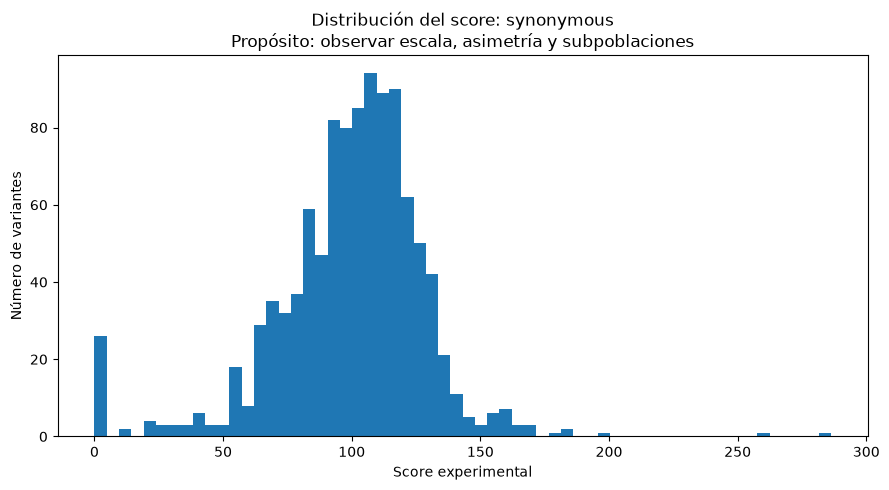

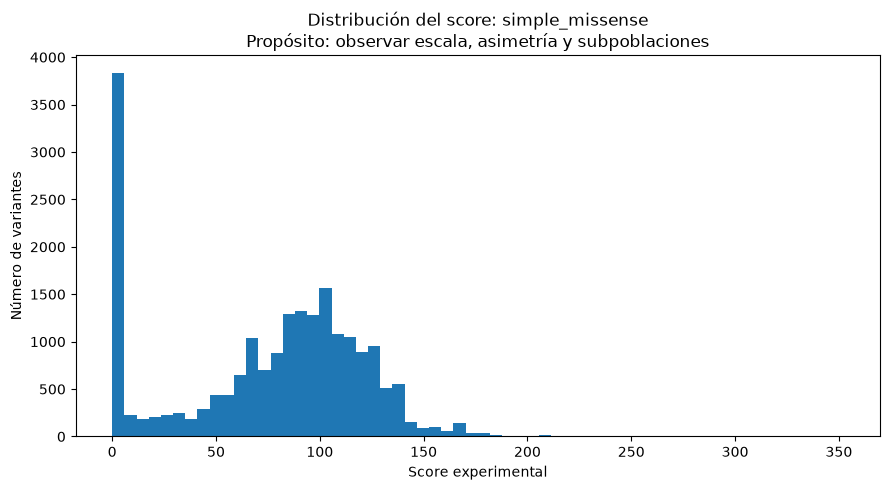

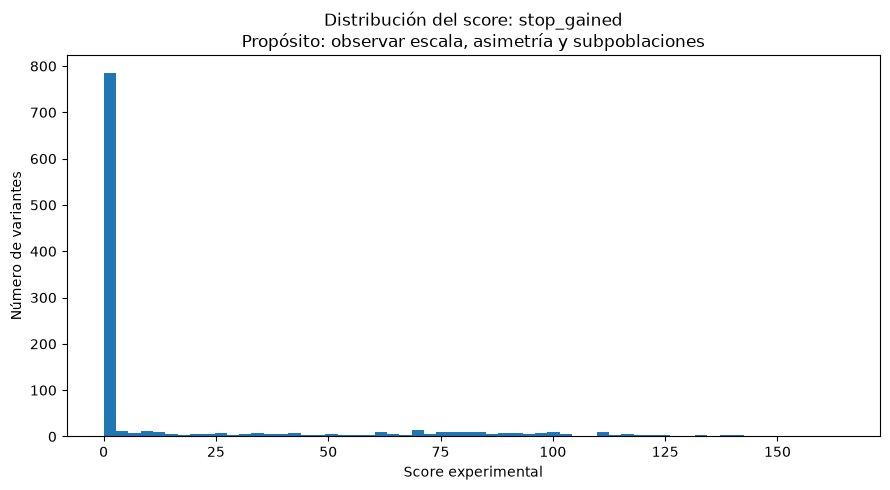

In [11]:
for variant_class in analysis_classes:
    values = score_by_class.loc[
        score_by_class["variant_class"].eq(
            variant_class
        ),
        "score_numeric",
    ]

    plt.figure(figsize=(9, 5))
    plt.hist(values, bins=60)
    plt.xlabel("Score experimental")
    plt.ylabel("Número de variantes")
    plt.title(
        f"Distribución del score: {variant_class}\n"
        "Propósito: observar escala, asimetría y subpoblaciones"
    )
    plt.tight_layout()
    plt.show()

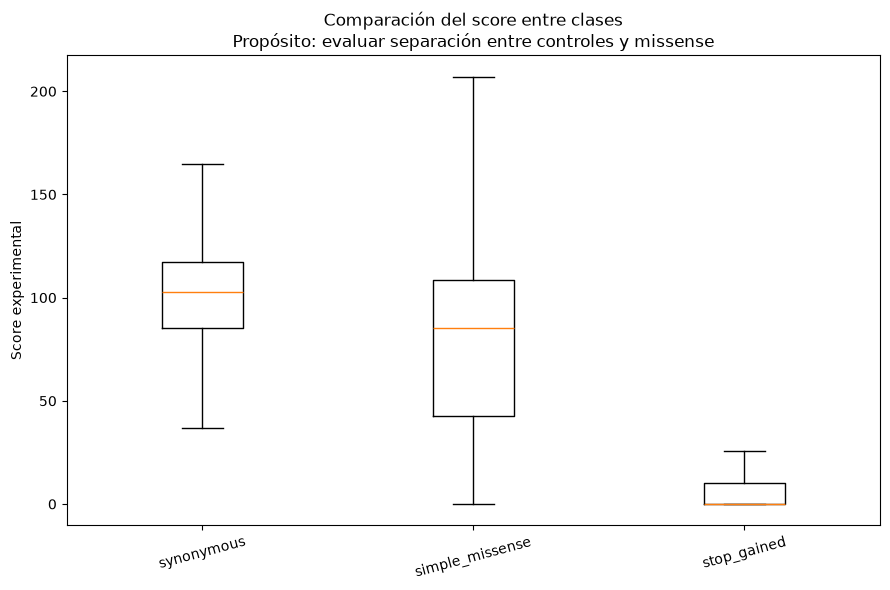

In [12]:
ordered_values = [
    score_by_class.loc[
        score_by_class["variant_class"].eq(label),
        "score_numeric",
    ].values
    for label in analysis_classes
]

plt.figure(figsize=(9, 6))
plt.boxplot(
    ordered_values,
    tick_labels=analysis_classes,
    showfliers=False,
)
plt.ylabel("Score experimental")
plt.title(
    "Comparación del score entre clases\n"
    "Propósito: evaluar separación entre controles y missense"
)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 7.1 Comparación estadística — propósito: cuantificar diferencias y solapamiento entre clases

Se utiliza Kruskal–Wallis y comparaciones Mann–Whitney porque no se asume normalidad. El tamaño de efecto por rangos muestra cuánto tiende una clase a presentar valores mayores que otra.

In [13]:
kruskal_result = stats.kruskal(*ordered_values)

print(
    f"Kruskal-Wallis H={kruskal_result.statistic:,.4f}, "
    f"p={kruskal_result.pvalue:.3e}"
)


def holm_adjust(
    p_values: Iterable[float],
) -> np.ndarray:
    p_values = np.asarray(
        list(p_values),
        dtype=float,
    )

    order = np.argsort(p_values)
    adjusted = np.empty_like(p_values)
    running_max = 0.0

    for rank, index in enumerate(order):
        adjusted_value = (
            len(p_values) - rank
        ) * p_values[index]

        running_max = max(
            running_max,
            adjusted_value,
        )

        adjusted[index] = min(
            running_max,
            1.0,
        )

    return adjusted


pairwise_results = []

for index, class_a in enumerate(
    analysis_classes
):
    for class_b in analysis_classes[
        index + 1 :
    ]:
        values_a = score_by_class.loc[
            score_by_class[
                "variant_class"
            ].eq(class_a),
            "score_numeric",
        ].values

        values_b = score_by_class.loc[
            score_by_class[
                "variant_class"
            ].eq(class_b),
            "score_numeric",
        ].values

        test = stats.mannwhitneyu(
            values_a,
            values_b,
            alternative="two-sided",
        )

        rank_biserial = (
            2
            * test.statistic
            / (len(values_a) * len(values_b))
        ) - 1

        pairwise_results.append(
            {
                "class_a": class_a,
                "class_b": class_b,
                "n_a": len(values_a),
                "n_b": len(values_b),
                "median_a": np.median(values_a),
                "median_b": np.median(values_b),
                "u_statistic": test.statistic,
                "p_value": test.pvalue,
                "rank_biserial_effect": (
                    rank_biserial
                ),
            }
        )

pairwise_df = pd.DataFrame(
    pairwise_results
)

pairwise_df["p_holm"] = holm_adjust(
    pairwise_df["p_value"]
)

display(pairwise_df)

pairwise_df.to_csv(
    EDA_REPORTS_DIR
    / "pairwise_score_class_tests.csv",
    index=False,
)

Kruskal-Wallis H=1,561.8033, p=0.000e+00


,class_a,class_b,n_a,n_b,median_a,median_b,u_statistic,p_value,rank_biserial_effect,p_holm
0,synonymous,simple_missense,1057,20683,102.8736,85.3655,"14,231,973.0000",0.0000,0.3020,0.0000
1,synonymous,stop_gained,1057,1084,102.8736,0.0000,"1,056,259.5000",0.0000,0.8437,0.0000
2,simple_missense,stop_gained,20683,1084,85.3655,0.0000,"18,314,111.0000",0.0000,0.6337,0.0000


## 8. Cobertura mutacional — propósito: distinguir tolerancia biológica de ausencia de medición

Cada posición admite hasta 19 sustituciones missense. Se calcula cuántas posiciones y sustituciones fueron evaluadas y dónde existen vacíos.

In [14]:
all_positions = pd.DataFrame(
    {
        "position": np.arange(
            1,
            len(reference_sequence) + 1,
        )
    }
)

coverage_observed = (
    missense_df.groupby("position")
    .agg(
        n_missense=("variant_id", "count"),
        n_unique_mutants=(
            "mut_aa1",
            "nunique",
        ),
        wt_residue=("wt_aa1", "first"),
    )
    .reset_index()
)

coverage_df = all_positions.merge(
    coverage_observed,
    on="position",
    how="left",
)

coverage_df["n_missense"] = (
    coverage_df["n_missense"]
    .fillna(0)
    .astype("int16")
)

coverage_df["n_unique_mutants"] = (
    coverage_df["n_unique_mutants"]
    .fillna(0)
    .astype("int16")
)

coverage_df["wt_residue"] = [
    reference_sequence[position - 1]
    for position in coverage_df["position"]
]

coverage_df["coverage_fraction"] = (
    coverage_df["n_missense"] / 19
)

coverage_df["fully_covered"] = (
    coverage_df["n_missense"].eq(19)
)

coverage_summary = pd.Series(
    {
        "protein_length": len(
            reference_sequence
        ),
        "positions_with_missense": int(
            coverage_df[
                "n_missense"
            ].gt(0).sum()
        ),
        "positions_without_missense": int(
            coverage_df[
                "n_missense"
            ].eq(0).sum()
        ),
        "fully_covered_positions": int(
            coverage_df[
                "fully_covered"
            ].sum()
        ),
        "observed_missense_variants": int(
            coverage_df[
                "n_missense"
            ].sum()
        ),
        "theoretical_missense_space": (
            len(reference_sequence) * 19
        ),
        "global_coverage_fraction": (
            coverage_df[
                "n_missense"
            ].sum()
            / (
                len(reference_sequence)
                * 19
            )
        ),
    },
    name="value",
)

display(coverage_summary.to_frame())

display(
    coverage_df.sort_values(
        ["n_missense", "position"]
    ).head(30)
)

coverage_df.to_csv(
    EDA_REPORTS_DIR
    / "coverage_by_position.csv",
    index=False,
)

,value
protein_length,"1,159.0000"
positions_with_missense,"1,100.0000"
positions_without_missense,59.0000
fully_covered_positions,967.0000
observed_missense_variants,"20,683.0000"
theoretical_missense_space,"22,021.0000"
global_coverage_fraction,0.9392


,position,n_missense,n_unique_mutants,wt_residue,coverage_fraction,fully_covered
0,1,0,0,M,0.0000,False
190,191,0,0,P,0.0000,False
228,229,0,0,E,0.0000,False
230,231,0,0,R,0.0000,False
231,232,0,0,R,0.0000,False
232,233,0,0,A,0.0000,False
233,234,0,0,L,0.0000,False
234,235,0,0,V,0.0000,False
382,383,0,0,D,0.0000,False
407,408,0,0,A,0.0000,False


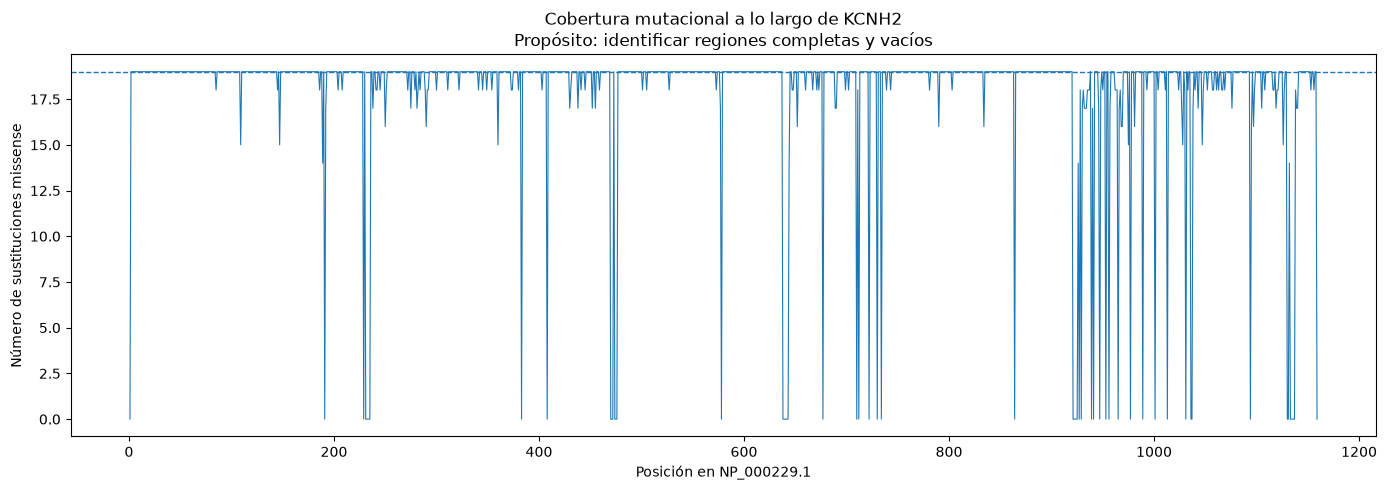

In [15]:
plt.figure(figsize=(14, 5))
plt.plot(
    coverage_df["position"],
    coverage_df["n_missense"],
    linewidth=0.8,
)
plt.axhline(
    19,
    linestyle="--",
    linewidth=1,
)
plt.xlabel("Posición en NP_000229.1")
plt.ylabel(
    "Número de sustituciones missense"
)
plt.title(
    "Cobertura mutacional a lo largo de KCNH2\n"
    "Propósito: identificar regiones completas y vacíos"
)
plt.tight_layout()
plt.show()

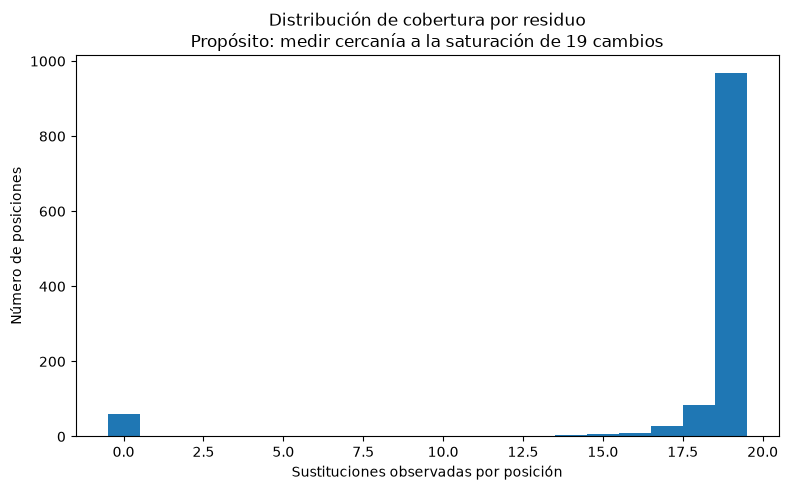

In [16]:
plt.figure(figsize=(8, 5))
plt.hist(
    coverage_df["n_missense"],
    bins=np.arange(-0.5, 20.5, 1),
)
plt.xlabel(
    "Sustituciones observadas por posición"
)
plt.ylabel("Número de posiciones")
plt.title(
    "Distribución de cobertura por residuo\n"
    "Propósito: medir cercanía a la saturación de 19 cambios"
)
plt.tight_layout()
plt.show()

## 9. Sensibilidad por residuo — propósito: localizar posiciones con scores consistentemente bajos o dependientes del aminoácido mutante

La mediana resume tolerancia global de una posición. El IQR resume cuánto cambia el resultado según el aminoácido introducido.

In [17]:
position_summary = (
    missense_df.groupby("position")
    .agg(
        wt_residue=("wt_aa1", "first"),
        n_variants=("variant_id", "count"),
        mean_score=(
            "score_numeric",
            "mean",
        ),
        median_score=(
            "score_numeric",
            "median",
        ),
        std_score=(
            "score_numeric",
            "std",
        ),
        min_score=("score_numeric", "min"),
        q1_score=(
            "score_numeric",
            lambda x: x.quantile(0.25),
        ),
        q3_score=(
            "score_numeric",
            lambda x: x.quantile(0.75),
        ),
        max_score=("score_numeric", "max"),
        median_se=("se", "median"),
    )
    .reset_index()
)

position_summary["iqr_score"] = (
    position_summary["q3_score"]
    - position_summary["q1_score"]
)

print("Posiciones con menor mediana:")
display(
    position_summary.sort_values(
        "median_score"
    ).head(20)
)

print("Posiciones con mayor mediana:")
display(
    position_summary.sort_values(
        "median_score",
        ascending=False,
    ).head(20)
)

position_summary.to_csv(
    EDA_REPORTS_DIR
    / "position_score_summary.csv",
    index=False,
)

Posiciones con menor mediana:


,position,wt_residue,n_variants,mean_score,median_score,std_score,min_score,q1_score,q3_score,max_score,median_se,iqr_score
58,60,M,19,38.0257,0.0000,53.2612,0.0000,0.0000,75.2758,146.2522,10.0465,75.2758
64,66,C,19,31.0474,0.0000,51.3678,0.0000,0.0000,57.0321,137.6419,9.0857,57.0321
452,463,F,19,1.9531,0.0000,8.5133,0.0000,0.0000,0.0000,37.1087,0.0000,0.0000
455,466,D,19,0.8147,0.0000,3.5514,0.0000,0.0000,0.0000,15.4802,0.0000,0.0000
457,468,L,19,34.9662,0.0000,50.3579,0.0000,0.0000,75.0785,166.5011,7.9279,75.0785
456,467,I,19,22.4113,0.0000,40.9286,0.0000,0.0000,28.6119,124.7876,6.7666,28.6119
593,611,Y,19,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.4624,0.0000
594,612,V,19,8.4507,0.0000,33.5508,0.0000,0.0000,0.0000,146.3438,9.3641,0.0000
598,616,Y,19,25.5972,0.0000,41.2605,0.0000,0.0000,54.5199,115.9858,14.3282,54.5199
595,613,T,19,3.4063,0.0000,14.8479,0.0000,0.0000,0.0000,64.7203,0.0000,0.0000


Posiciones con mayor mediana:


,position,wt_residue,n_variants,mean_score,median_score,std_score,min_score,q1_score,q3_score,max_score,median_se,iqr_score
422,433,L,19,131.1000,138.2662,39.5188,41.3795,112.9719,158.2343,179.4948,20.1254,45.2623
165,167,L,19,129.0682,137.9799,36.9557,69.3932,96.6146,149.1595,195.2751,15.8977,52.5449
560,577,P,17,128.7770,132.9582,35.9374,32.3602,125.1770,146.3438,179.2012,23.9086,21.1668
500,517,S,19,127.3341,131.1994,17.3768,97.0805,117.8226,133.8372,161.8008,21.0927,16.0146
501,518,E,19,124.8015,129.4406,24.6428,75.9512,110.8505,138.7716,164.3505,19.1492,27.9211
561,579,M,19,119.2617,129.4406,35.5557,20.5286,108.0615,146.3438,158.4765,20.8019,38.2823
161,163,F,19,118.6601,128.8845,25.7815,73.6353,93.4213,138.7863,146.4625,14.1101,45.3650
171,173,L,19,122.6212,128.8845,24.8894,38.4488,116.4479,138.7863,146.4625,18.0112,22.3384
7,9,A,19,118.0136,128.6094,23.3024,75.2651,101.3337,133.4974,160.8221,20.4364,32.1637
331,340,F,19,132.0583,127.5860,25.1229,85.0573,124.0814,155.4205,167.4038,13.3016,31.3391


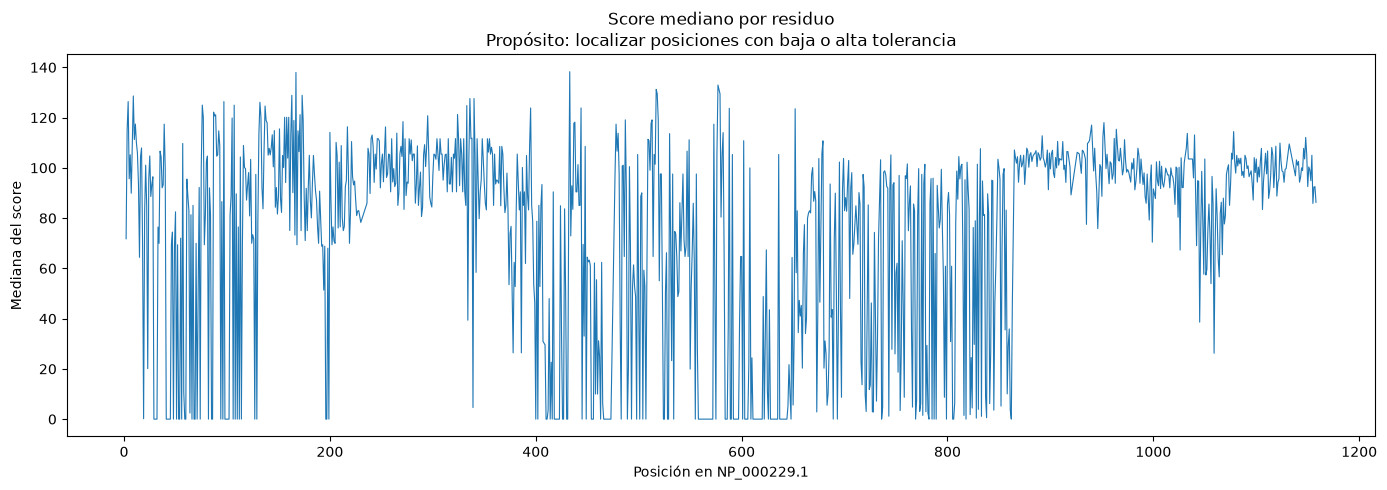

In [18]:
plt.figure(figsize=(14, 5))
plt.plot(
    position_summary["position"],
    position_summary["median_score"],
    linewidth=0.8,
)
plt.xlabel("Posición en NP_000229.1")
plt.ylabel("Mediana del score")
plt.title(
    "Score mediano por residuo\n"
    "Propósito: localizar posiciones con baja o alta tolerancia"
)
plt.tight_layout()
plt.show()

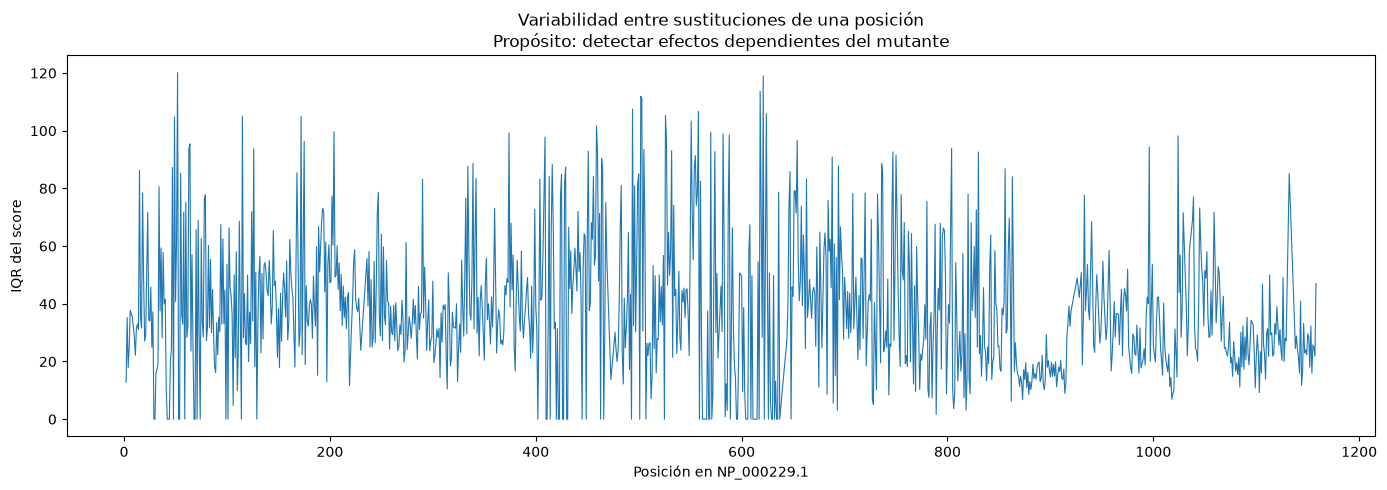

In [19]:
plt.figure(figsize=(14, 5))
plt.plot(
    position_summary["position"],
    position_summary["iqr_score"],
    linewidth=0.8,
)
plt.xlabel("Posición en NP_000229.1")
plt.ylabel("IQR del score")
plt.title(
    "Variabilidad entre sustituciones de una posición\n"
    "Propósito: detectar efectos dependientes del mutante"
)
plt.tight_layout()
plt.show()

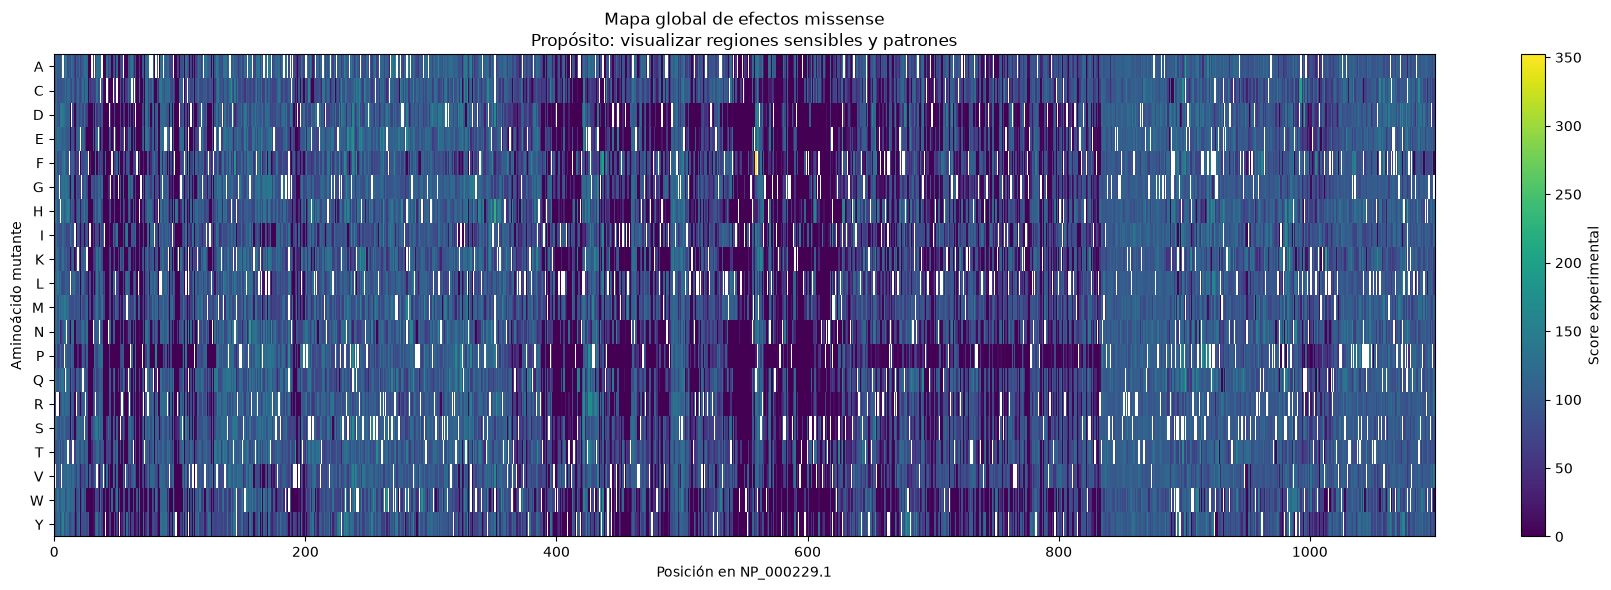

In [20]:
canonical_amino_acids = list(
    "ACDEFGHIKLMNPQRSTVWY"
)

mutational_matrix = (
    missense_df.pivot_table(
        index="mut_aa1",
        columns="position",
        values="score_numeric",
        aggfunc="mean",
    )
    .reindex(canonical_amino_acids)
)

plt.figure(figsize=(18, 6))
image = plt.imshow(
    mutational_matrix,
    aspect="auto",
    interpolation="nearest",
)
plt.colorbar(
    image,
    label="Score experimental",
)
plt.yticks(
    ticks=np.arange(
        len(canonical_amino_acids)
    ),
    labels=canonical_amino_acids,
)
plt.xlabel("Posición en NP_000229.1")
plt.ylabel("Aminoácido mutante")
plt.title(
    "Mapa global de efectos missense\n"
    "Propósito: visualizar regiones sensibles y patrones"
)
plt.tight_layout()
plt.show()

## 10. Propiedades fisicoquímicas — propósito: evaluar si cambios moleculares interpretables explican parte del score

Se analizan hidrofobicidad, carga, polaridad y BLOSUM62. Estas variables serán el baseline interpretable que posteriormente se comparará con ESM-2.

In [21]:
HYDROPHOBICITY_KD = {
    "A": 1.8,
    "R": -4.5,
    "N": -3.5,
    "D": -3.5,
    "C": 2.5,
    "Q": -3.5,
    "E": -3.5,
    "G": -0.4,
    "H": -3.2,
    "I": 4.5,
    "L": 3.8,
    "K": -3.9,
    "M": 1.9,
    "F": 2.8,
    "P": -1.6,
    "S": -0.8,
    "T": -0.7,
    "W": -0.9,
    "Y": -1.3,
    "V": 4.2,
}

CHARGE_CLASS = {
    "D": "negative",
    "E": "negative",
    "K": "positive",
    "R": "positive",
    "H": "positive",
    "A": "neutral",
    "C": "neutral",
    "F": "neutral",
    "G": "neutral",
    "I": "neutral",
    "L": "neutral",
    "M": "neutral",
    "N": "neutral",
    "P": "neutral",
    "Q": "neutral",
    "S": "neutral",
    "T": "neutral",
    "V": "neutral",
    "W": "neutral",
    "Y": "neutral",
}

POLARITY_CLASS = {
    aa: (
        "polar"
        if aa in set("RNDQEKHSTY")
        else "nonpolar"
    )
    for aa in HYDROPHOBICITY_KD
}

blosum62 = substitution_matrices.load(
    "BLOSUM62"
)


def get_blosum_score(
    wt: str,
    mut: str,
) -> float:
    try:
        return float(blosum62[wt, mut])
    except (IndexError, KeyError):
        return float(blosum62[mut, wt])


feature_df = missense_df.copy()

feature_df["wt_hydrophobicity"] = (
    feature_df["wt_aa1"].map(
        HYDROPHOBICITY_KD
    )
)

feature_df["mut_hydrophobicity"] = (
    feature_df["mut_aa1"].map(
        HYDROPHOBICITY_KD
    )
)

feature_df["delta_hydrophobicity"] = (
    feature_df["mut_hydrophobicity"]
    - feature_df["wt_hydrophobicity"]
)

feature_df[
    "abs_delta_hydrophobicity"
] = feature_df[
    "delta_hydrophobicity"
].abs()

feature_df["wt_charge"] = (
    feature_df["wt_aa1"].map(
        CHARGE_CLASS
    )
)

feature_df["mut_charge"] = (
    feature_df["mut_aa1"].map(
        CHARGE_CLASS
    )
)

feature_df["charge_change"] = np.where(
    feature_df["wt_charge"].eq(
        feature_df["mut_charge"]
    ),
    "same_charge_class",
    feature_df["wt_charge"]
    + "_to_"
    + feature_df["mut_charge"],
)

feature_df["wt_polarity"] = (
    feature_df["wt_aa1"].map(
        POLARITY_CLASS
    )
)

feature_df["mut_polarity"] = (
    feature_df["mut_aa1"].map(
        POLARITY_CLASS
    )
)

feature_df["polarity_change"] = np.where(
    feature_df["wt_polarity"].eq(
        feature_df["mut_polarity"]
    ),
    "same_polarity_class",
    feature_df["wt_polarity"]
    + "_to_"
    + feature_df["mut_polarity"],
)

feature_df["blosum62"] = [
    get_blosum_score(wt, mut)
    for wt, mut in zip(
        feature_df["wt_aa1"],
        feature_df["mut_aa1"],
    )
]

display(
    feature_df[
        [
            "variant_id",
            "score_numeric",
            "delta_hydrophobicity",
            "charge_change",
            "polarity_change",
            "blosum62",
        ]
    ].head()
)

,variant_id,score_numeric,delta_hydrophobicity,charge_change,polarity_change,blosum62
0,P2A,69.3932,3.4000,same_charge_class,same_polarity_class,-1.0000
1,P2C,0.0000,4.1000,same_charge_class,same_polarity_class,-3.0000
2,P2D,64.0233,-1.9000,neutral_to_negative,nonpolar_to_polar,-1.0000
3,P2E,53.3915,-1.9000,neutral_to_negative,nonpolar_to_polar,-1.0000
4,P2F,69.9654,4.4000,same_charge_class,same_polarity_class,-4.0000


In [22]:
correlation_rows = []

for feature in [
    "delta_hydrophobicity",
    "abs_delta_hydrophobicity",
    "blosum62",
]:
    valid = feature_df[
        [feature, "score_numeric"]
    ].dropna()

    result = stats.spearmanr(
        valid[feature],
        valid["score_numeric"],
    )

    correlation_rows.append(
        {
            "feature": feature,
            "n": len(valid),
            "spearman_rho": (
                result.statistic
            ),
            "p_value": result.pvalue,
        }
    )

physicochemical_correlations_df = (
    pd.DataFrame(correlation_rows)
)

display(
    physicochemical_correlations_df
)

physicochemical_correlations_df.to_csv(
    EDA_REPORTS_DIR
    / "physicochemical_correlations.csv",
    index=False,
)

,feature,n,spearman_rho,p_value
0,delta_hydrophobicity,20683,0.1066,0.0000
1,abs_delta_hydrophobicity,20683,-0.1296,0.0000
2,blosum62,20683,0.2010,0.0000


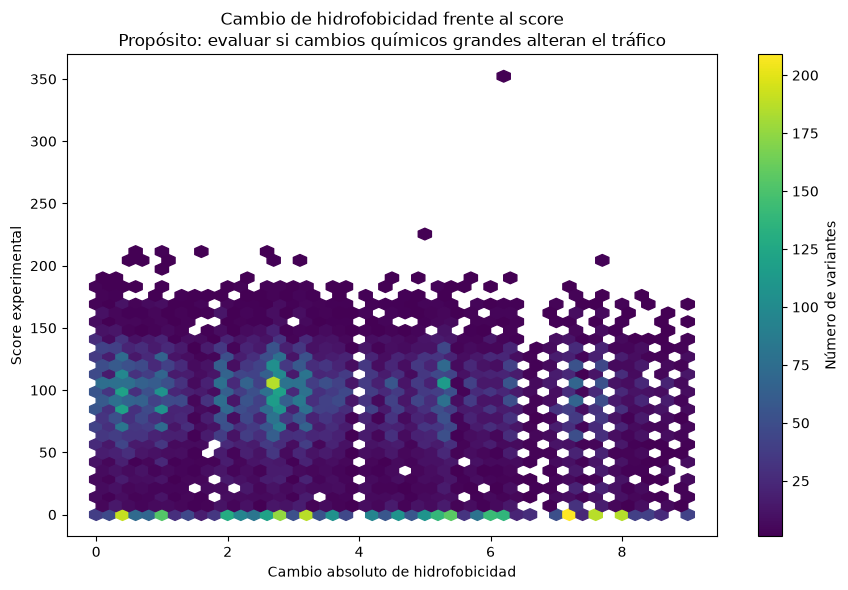

In [23]:
plt.figure(figsize=(9, 6))
plt.hexbin(
    feature_df[
        "abs_delta_hydrophobicity"
    ],
    feature_df["score_numeric"],
    gridsize=45,
    mincnt=1,
)
plt.colorbar(
    label="Número de variantes"
)
plt.xlabel(
    "Cambio absoluto de hidrofobicidad"
)
plt.ylabel("Score experimental")
plt.title(
    "Cambio de hidrofobicidad frente al score\n"
    "Propósito: evaluar si cambios químicos grandes alteran el tráfico"
)
plt.tight_layout()
plt.show()

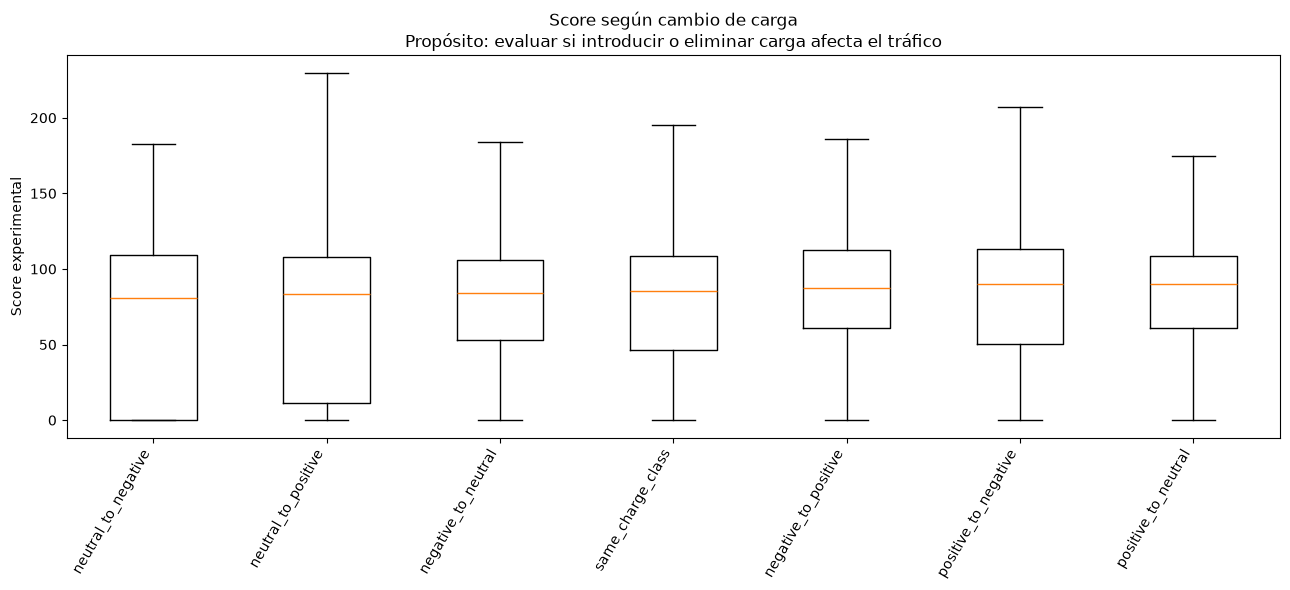

In [24]:
charge_order = (
    feature_df.groupby(
        "charge_change"
    )["score_numeric"]
    .median()
    .sort_values()
    .index
    .tolist()
)

charge_values = [
    feature_df.loc[
        feature_df["charge_change"].eq(
            label
        ),
        "score_numeric",
    ].values
    for label in charge_order
]

plt.figure(figsize=(13, 6))
plt.boxplot(
    charge_values,
    tick_labels=charge_order,
    showfliers=False,
)
plt.ylabel("Score experimental")
plt.title(
    "Score según cambio de carga\n"
    "Propósito: evaluar si introducir o eliminar carga afecta el tráfico"
)
plt.xticks(
    rotation=60,
    ha="right",
)
plt.tight_layout()
plt.show()

## 11. Incertidumbre experimental — propósito: distinguir scores precisos de estimaciones inestables

Se revisan `se`, intervalos del LLR y fuerza de evidencia. Aún no se filtran variantes; primero se caracteriza la incertidumbre.

In [25]:
uncertainty_columns = [
    "se",
    "LLR",
    "LLR_ci_lower",
    "LLR_ci_upper",
    "LLR_evidence_strength",
]

uncertainty_missing = pd.DataFrame(
    {
        "column": uncertainty_columns,
        "missing_count": [
            qc_df[column].isna().sum()
            for column in uncertainty_columns
        ],
        "missing_percentage": [
            qc_df[column].isna().mean()
            * 100
            for column in uncertainty_columns
        ],
    }
)

display(uncertainty_missing)

qc_df["LLR_ci_width"] = (
    qc_df["LLR_ci_upper"]
    - qc_df["LLR_ci_lower"]
)

display(
    qc_df[
        ["se", "LLR", "LLR_ci_width"]
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.5,
            0.75,
            0.95,
            0.99,
        ]
    )
)

,column,missing_count,missing_percentage
0,se,197,0.8631
1,LLR,0,0.0000
2,LLR_ci_lower,197,0.8631
3,LLR_ci_upper,197,0.8631
4,LLR_evidence_strength,2270,9.9457


,se,LLR,LLR_ci_width
count,"22,627.0000","22,824.0000","22,627.0000"
mean,13.0351,0.4116,1.7211
std,9.4411,2.1623,1.6040
min,0.0000,-3.4599,0.0000
1%,0.0000,-3.0015,0.0000
5%,0.0000,-1.6005,0.0000
25%,6.4298,-1.0202,0.3310
50%,11.8862,-0.7437,1.2790
75%,18.0656,3.4435,2.6580
95%,29.1225,4.0045,4.8467


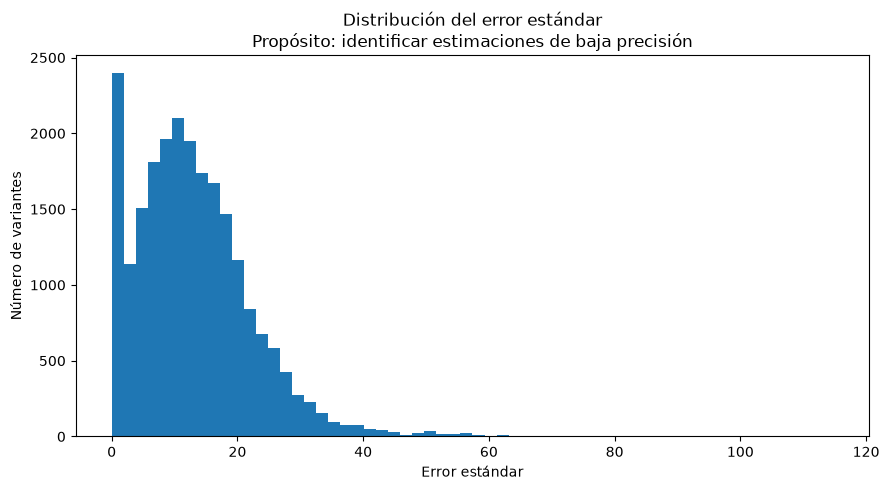

In [26]:
se_values = qc_df["se"].dropna()

plt.figure(figsize=(9, 5))
plt.hist(se_values, bins=60)
plt.xlabel("Error estándar")
plt.ylabel("Número de variantes")
plt.title(
    "Distribución del error estándar\n"
    "Propósito: identificar estimaciones de baja precisión"
)
plt.tight_layout()
plt.show()

Spearman score vs se: rho=0.3496, p=0.000e+00


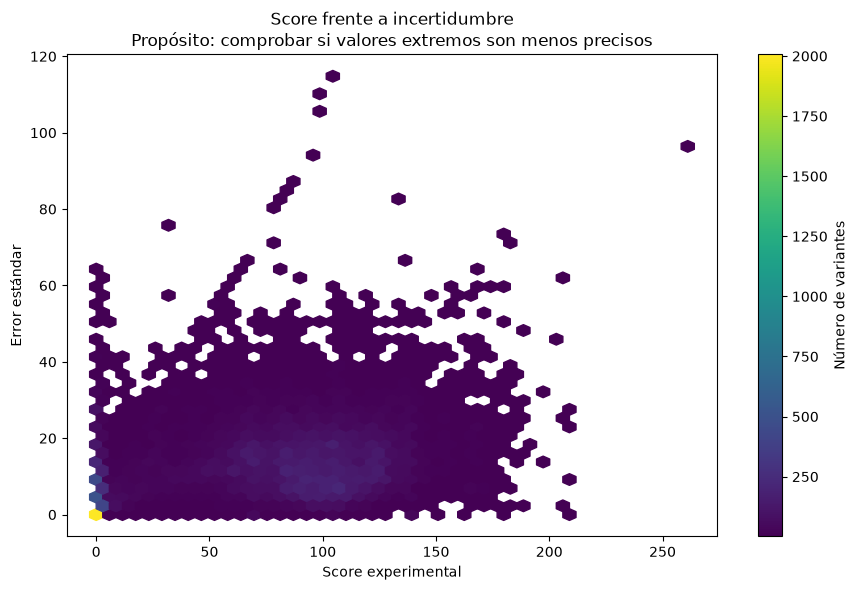

In [27]:
valid_se = qc_df[
    ["score_numeric", "se"]
].dropna()

se_score_corr = stats.spearmanr(
    valid_se["score_numeric"],
    valid_se["se"],
)

print(
    "Spearman score vs se: "
    f"rho={se_score_corr.statistic:.4f}, "
    f"p={se_score_corr.pvalue:.3e}"
)

plt.figure(figsize=(9, 6))
plt.hexbin(
    valid_se["score_numeric"],
    valid_se["se"],
    gridsize=45,
    mincnt=1,
)
plt.colorbar(
    label="Número de variantes"
)
plt.xlabel("Score experimental")
plt.ylabel("Error estándar")
plt.title(
    "Score frente a incertidumbre\n"
    "Propósito: comprobar si valores extremos son menos precisos"
)
plt.tight_layout()
plt.show()

In [28]:
evidence_counts = (
    qc_df["LLR_evidence_strength"]
    .fillna("MISSING")
    .value_counts(dropna=False)
    .rename_axis(
        "LLR_evidence_strength"
    )
    .reset_index(name="count")
)

evidence_counts["percentage"] = (
    evidence_counts["count"]
    / len(qc_df)
    * 100
)

display(evidence_counts)

missing_se_by_class = (
    qc_df.assign(
        se_missing=qc_df["se"].isna()
    )
    .groupby(
        "variant_class"
    )["se_missing"]
    .agg(["sum", "mean", "count"])
    .rename(
        columns={
            "sum": "missing_se_count",
            "mean": (
                "missing_se_fraction"
            ),
            "count": "class_count",
        }
    )
)

display(missing_se_by_class)

,LLR_evidence_strength,count,percentage
0,benign supporting,11352,49.7371
1,pathogenic very strong,5752,25.2015
2,MISSING,2270,9.9457
3,benign strong,2085,9.1351
4,pathogenic supporting,625,2.7383
5,pathogenic moderate,510,2.2345
6,pathogenic strong,230,1.0077


,missing_se_count,missing_se_fraction,class_count
variant_class,,,
simple_missense,160,0.0077,20683
stop_gained,17,0.0157,1084
synonymous,20,0.0189,1057


## 12. Score y LLR — propósito: detectar dependencia y prevenir target leakage

Si `LLR` se deriva del mismo resultado experimental, no debe utilizarse como feature para predecir `score`. Puede utilizarse para control de calidad o análisis de sensibilidad.

,metric,coefficient,p_value,n
0,Spearman,-0.9941,0.0000,22824
1,Pearson,-0.9595,0.0000,22824


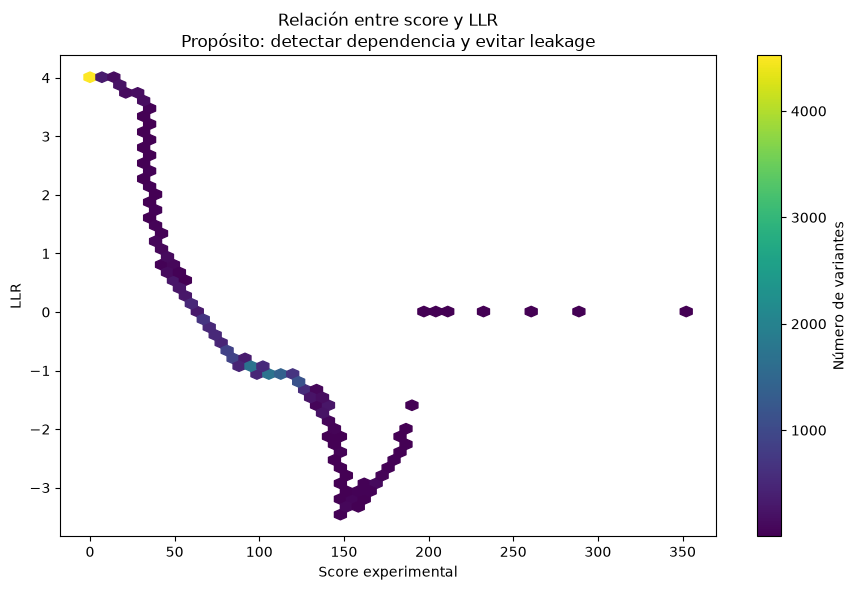

In [29]:
valid_llr = qc_df[
    ["score_numeric", "LLR"]
].dropna()

spearman_llr = stats.spearmanr(
    valid_llr["score_numeric"],
    valid_llr["LLR"],
)

pearson_llr = stats.pearsonr(
    valid_llr["score_numeric"],
    valid_llr["LLR"],
)

llr_relationship = pd.DataFrame(
    {
        "metric": [
            "Spearman",
            "Pearson",
        ],
        "coefficient": [
            spearman_llr.statistic,
            pearson_llr.statistic,
        ],
        "p_value": [
            spearman_llr.pvalue,
            pearson_llr.pvalue,
        ],
        "n": [
            len(valid_llr),
            len(valid_llr),
        ],
    }
)

display(llr_relationship)

plt.figure(figsize=(9, 6))
plt.hexbin(
    valid_llr["score_numeric"],
    valid_llr["LLR"],
    gridsize=50,
    mincnt=1,
)
plt.colorbar(
    label="Número de variantes"
)
plt.xlabel("Score experimental")
plt.ylabel("LLR")
plt.title(
    "Relación entre score y LLR\n"
    "Propósito: detectar dependencia y evitar leakage"
)
plt.tight_layout()
plt.show()

## 13. `mapped_variants.json` — propósito: evaluar la futura interoperabilidad con ClinVar y GA4GH

Se inspecciona la estructura, identificadores GA4GH y accessions. La integración detallada se pospone hasta la armonización clínica.

In [30]:
with MAPPED_VARIANTS_PATH.open(
    "r",
    encoding="utf-8",
) as file:
    mapped_variants = json.load(file)


def summarize_json_node(
    obj: Any,
) -> dict[str, Any]:
    if isinstance(obj, dict):
        return {
            "root_type": "dict",
            "root_length": len(obj),
            "first_keys": list(
                obj.keys()
            )[:30],
        }

    if isinstance(obj, list):
        return {
            "root_type": "list",
            "root_length": len(obj),
            "first_item_type": (
                type(obj[0]).__name__
                if obj
                else None
            ),
            "first_item_keys": (
                list(obj[0].keys())[:30]
                if obj
                and isinstance(
                    obj[0],
                    dict,
                )
                else None
            ),
        }

    return {
        "root_type": (
            type(obj).__name__
        ),
        "root_length": None,
    }


mapped_structure = summarize_json_node(
    mapped_variants
)

display(
    pd.Series(
        mapped_structure,
        name="value",
    ).to_frame()
)

mapped_text = json.dumps(
    mapped_variants,
    ensure_ascii=False,
)

ga4gh_ids = sorted(
    set(
        re.findall(
            r"ga4gh:[A-Za-z0-9._-]+",
            mapped_text,
        )
    )
)

reference_accessions = sorted(
    set(
        re.findall(
            r"\b(?:NP|NM|NC|NG|ENSP|ENST)_?\d+(?:\.\d+)?\b",
            mapped_text,
        )
    )
)

print(
    "Unique GA4GH-like IDs:",
    f"{len(ga4gh_ids):,}",
)
print(
    "First GA4GH IDs:",
    ga4gh_ids[:10],
)
print(
    "Reference accessions:",
    reference_accessions[:30],
)

if (
    isinstance(mapped_variants, list)
    and mapped_variants
    and isinstance(
        mapped_variants[0],
        dict,
    )
):
    display(
        pd.json_normalize(
            mapped_variants[:5],
            max_level=2,
        )
    )

,value
root_type,list
root_length,45648
first_item_type,dict
first_item_keys,"[preMapped, postMapped, vrsVersion, errorMessage, modificationDate, mappedDate, mappingApiVersion, current, alignmentLevel, atMismatchedLocus, nearGap, vari..."


Unique GA4GH-like IDs: 23,924
First GA4GH IDs: ['ga4gh:SL.-1UCrK-NsrLIH4J8oCUVeGFT5wKzHtzT', 'ga4gh:SL.-3g0vg1Xos9xhXPtdaTo32_J_K0Nted0', 'ga4gh:SL.-6LeRHg-qJEX_PmhMADBoxR3BL77eFus', 'ga4gh:SL.-8o1kCHwm2yi7K9FS9eedCyBQym_RBsv', 'ga4gh:SL.-A9aVBqnkuQ74tJfYyJUSqxvgPXu9IzU', 'ga4gh:SL.-CA2U3jTC8TQfj8q7AO-yljpaooeWiQi', 'ga4gh:SL.-DJwlCsH21SODzgUoW5-mVnb6eLg6Ehh', 'ga4gh:SL.-Ewbn_Q0OOsyylQf0AdMDrAXkX7pOZ3-', 'ga4gh:SL.-F5z2CuAoc4vdTKNcpK5tZL92Zk8o_jG', 'ga4gh:SL.-LrcBbyFiRrzyk0xDHzM6EchcrAo1ICk']
Reference accessions: ['NP_000229.1']


,vrsVersion,errorMessage,modificationDate,mappedDate,mappingApiVersion,current,alignmentLevel,atMismatchedLocus,nearGap,variantUrn,id,clingenAlleleId,recordType,preMapped.id,preMapped.type,preMapped.state.type,preMapped.state.sequence,preMapped.digest,preMapped.location.id,preMapped.location.end,preMapped.location.type,preMapped.location.start,preMapped.location.digest,preMapped.location.sequenceReference,preMapped.extensions,postMapped.id,postMapped.type,postMapped.state.type,postMapped.state.sequence,postMapped.digest,postMapped.location.id,postMapped.location.end,postMapped.location.type,postMapped.location.start,postMapped.location.digest,postMapped.location.sequenceReference,postMapped.extensions,postMapped.expressions
0,2,None,2026-05-29,2026-05-29,2026.2.0,True,protein,False,False,urn:mavedb:00001231-a-2#1,7378301,PA3057699036,MappedVariant,ga4gh:VA.ilDitVyCH7KPSLYETdvGo3f2hdrYbOuA,Allele,LiteralSequenceExpression,A,ilDitVyCH7KPSLYETdvGo3f2hdrYbOuA,ga4gh:SL.DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,2,SequenceLocation,1,DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,"{'type': 'SequenceReference', 'refgetAccession': 'SQ.y2xXsGuwhsLyy_KehonRzgroi7mTfRRR'}","[{'name': 'vrs_ref_allele_seq', 'type': 'Extension', 'value': 'P'}]",ga4gh:VA.ilDitVyCH7KPSLYETdvGo3f2hdrYbOuA,Allele,LiteralSequenceExpression,A,ilDitVyCH7KPSLYETdvGo3f2hdrYbOuA,ga4gh:SL.DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,2,SequenceLocation,1,DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,"{'type': 'SequenceReference', 'label': 'NP_000229.1', 'refgetAccession': 'SQ.UFpWsDMKsAW-XCCTpK4G9XEREMwBHejz'}","[{'name': 'vrs_ref_allele_seq', 'type': 'Extension', 'value': 'P'}]","[{'value': 'NP_000229.1:p.Pro2Ala', 'syntax': 'hgvs.p'}]"
1,2,None,2026-05-29,2025-10-04,2025.2.0,False,protein,None,None,urn:mavedb:00001231-a-2#1,5979778,PA3057699036,MappedVariant,ga4gh:VA.ilDitVyCH7KPSLYETdvGo3f2hdrYbOuA,Allele,LiteralSequenceExpression,A,ilDitVyCH7KPSLYETdvGo3f2hdrYbOuA,ga4gh:SL.DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,2,SequenceLocation,1,DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,"{'type': 'SequenceReference', 'refgetAccession': 'SQ.y2xXsGuwhsLyy_KehonRzgroi7mTfRRR'}","[{'name': 'vrs_ref_allele_seq', 'type': 'Extension', 'value': 'P'}]",ga4gh:VA.ilDitVyCH7KPSLYETdvGo3f2hdrYbOuA,Allele,LiteralSequenceExpression,A,ilDitVyCH7KPSLYETdvGo3f2hdrYbOuA,ga4gh:SL.DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,2,SequenceLocation,1,DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,"{'type': 'SequenceReference', 'label': 'NP_000229.1', 'refgetAccession': 'SQ.UFpWsDMKsAW-XCCTpK4G9XEREMwBHejz'}","[{'name': 'vrs_ref_allele_seq', 'type': 'Extension', 'value': 'P'}]","[{'value': 'NP_000229.1:p.Pro2Ala', 'syntax': 'hgvs.p'}]"
2,2,None,2026-05-29,2025-10-04,2025.2.0,False,protein,None,None,urn:mavedb:00001231-a-2#2,5979779,PA3057699037,MappedVariant,ga4gh:VA.wM4YFM7Fn4vwpKFcjIR8_alRv8VgWH7U,Allele,LiteralSequenceExpression,C,wM4YFM7Fn4vwpKFcjIR8_alRv8VgWH7U,ga4gh:SL.DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,2,SequenceLocation,1,DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,"{'type': 'SequenceReference', 'refgetAccession': 'SQ.y2xXsGuwhsLyy_KehonRzgroi7mTfRRR'}","[{'name': 'vrs_ref_allele_seq', 'type': 'Extension', 'value': 'P'}]",ga4gh:VA.wM4YFM7Fn4vwpKFcjIR8_alRv8VgWH7U,Allele,LiteralSequenceExpression,C,wM4YFM7Fn4vwpKFcjIR8_alRv8VgWH7U,ga4gh:SL.DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,2,SequenceLocation,1,DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,"{'type': 'SequenceReference', 'label': 'NP_000229.1', 'refgetAccession': 'SQ.UFpWsDMKsAW-XCCTpK4G9XEREMwBHejz'}","[{'name': 'vrs_ref_allele_seq', 'type': 'Extension', 'value': 'P'}]","[{'value': 'NP_000229.1:p.Pro2Cys', 'syntax': 'hgvs.p'}]"
3,2,None,2026-05-29,2026-05-29,2026.2.0,True,protein,False,False,urn:mavedb:00001231-a-2#2,7378302,PA3057699037,MappedVariant,ga4gh:VA.wM4YFM7Fn4vwpKFcjIR8_alRv8VgWH7U,Allele,LiteralSequenceExpression,C,wM4YFM7Fn4vwpKFcjIR8_alRv8VgWH7U,ga4gh:SL.DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,2,SequenceLocation,1,DyNbMkVyGIxAa1PoX63xggeeasjUOMcV,"{'type': 'SequenceReference', 'refgetAccession': 'SQ.y2xXsGuwhsLyy_KehonRzgroi7mTfRRR'}","[{'name': 'vrs_ref_all

## 14. Protein-domain analysis — purpose: determine whether trafficking defects cluster in specific structural and topological regions

This section integrates curated UniProtKB annotations with the MaveDB missense map.

Biological interpretation:

- **Domain:** a region with a defined structural or functional role.
- **Transmembrane segment:** a hydrophobic helix crossing the lipid membrane.
- **Topological domain:** a protein segment located on the cytoplasmic or extracellular side.
- **Region or motif:** a sequence interval with an annotated functional property.

The analysis asks whether variants inside each feature have systematically lower trafficking scores than variants outside it. Features may overlap, so every feature is analyzed independently rather than forcing each residue into one exclusive category.


In [31]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
from IPython.display import Markdown, display


FEATURES_PATH = (
    ROOT_DIR
    / "data"
    / "external"
    / "kcnh2_uniprot_features.csv"
)

DOMAINS_PATH = (
    ROOT_DIR
    / "data"
    / "external"
    / "kcnh2_domains.csv"
)

if not FEATURES_PATH.exists():
    raise FileNotFoundError(
        "Missing UniProt feature table. Run:\n"
        "python src/cardiovus/data/"
        "download_uniprot_features.py"
    )

features_df = pd.read_csv(FEATURES_PATH)
domains_df = pd.read_csv(DOMAINS_PATH)

required_columns = {
    "feature_label",
    "feature_type",
    "feature_group",
    "start",
    "end",
    "length",
}

missing_columns = (
    required_columns
    - set(features_df.columns)
)

if missing_columns:
    raise ValueError(
        "Missing annotation columns: "
        f"{sorted(missing_columns)}"
    )

assert features_df["start"].ge(1).all()
assert features_df["end"].le(
    len(reference_sequence)
).all()
assert features_df["start"].le(
    features_df["end"]
).all()

print("Feature counts by annotation layer:")
display(
    features_df[
        "feature_group"
    ]
    .value_counts()
    .rename_axis("feature_group")
    .reset_index(name="count")
)

display(
    features_df[
        [
            "feature_label",
            "feature_type",
            "feature_group",
            "start",
            "end",
            "length",
            "evidence_codes",
        ]
    ]
)

Feature counts by annotation layer:


,feature_group,count
0,topology,8
1,membrane,7
2,region,5
3,domain,2
4,motif,1
5,structure,1


,feature_label,feature_type,feature_group,start,end,length,evidence_codes
0,PAS,Domain,domain,41,70,30,ECO:0000255
1,PAC,Domain,domain,92,144,53,ECO:0000255
2,Helical; Name=Segment S1,Transmembrane,membrane,404,424,21,ECO:0000255
3,Helical; Name=Segment S2,Transmembrane,membrane,451,471,21,ECO:0000255
4,Helical; Name=Segment S3,Transmembrane,membrane,496,516,21,ECO:0000255
5,Helical; Voltage-sensor; Name=Segment S4,Transmembrane,membrane,521,541,21,ECO:0000255
6,Helical; Name=Segment S5,Transmembrane,membrane,548,568,21,ECO:0000255
7,Pore-forming; Name=Segment H5,Intramembrane,membrane,612,632,21,ECO:0000255
8,Helical; Name=Segment S6,Transmembrane,membrane,639,659,21,ECO:0000255
9,Selectivity filter,Motif,motif,624,629,6,ECO:0000250


### 14.1 Functional categories — purpose: summarize trafficking behavior without converting it into a clinical diagnosis

The associated MAVE study defines approximately 58–153% of wild-type trafficking as the normal functional range. Scores below 58 indicate reduced trafficking, and scores below 35 represent severe loss of trafficking in the assay calibration.

These categories describe the molecular assay only. They are not final ACMG/AMP classifications.


In [32]:
LOW_TRAFFICKING_THRESHOLD = 58.0
SEVERE_LOSS_THRESHOLD = 35.0
WT_LIKE_UPPER_THRESHOLD = 153.0


def assign_trafficking_category(
    score: float,
) -> str:
    if score < SEVERE_LOSS_THRESHOLD:
        return "severe_loss_lt_35"

    if score < LOW_TRAFFICKING_THRESHOLD:
        return "reduced_35_to_58"

    if score <= WT_LIKE_UPPER_THRESHOLD:
        return "wt_like_58_to_153"

    return "above_wt_gt_153"


domain_variant_base = missense_df.copy()

domain_variant_base[
    "trafficking_category"
] = domain_variant_base[
    "score_numeric"
].apply(assign_trafficking_category)

display(
    domain_variant_base[
        "trafficking_category"
    ]
    .value_counts()
    .rename_axis("category")
    .reset_index(name="count")
)


,category,count
0,wt_like_58_to_153,14105
1,severe_loss_lt_35,4909
2,reduced_35_to_58,1270
3,above_wt_gt_153,399


### 14.2 Position-level annotation — purpose: map every residue to all overlapping UniProt features

A residue can belong to more than one annotation. For example, it may lie inside a broad ion-channel region and also inside a transmembrane helix. We therefore create a **long-format membership table** rather than assigning a single domain.


In [33]:
analysis_groups = {
    "domain",
    "region",
    "membrane",
    "topology",
}

analysis_features = features_df.loc[
    features_df[
        "feature_group"
    ].isin(analysis_groups)
].copy()

membership_rows = []

for feature in analysis_features.itertuples(
    index=False
):
    for position in range(
        int(feature.start),
        int(feature.end) + 1,
    ):
        membership_rows.append(
            {
                "position": position,
                "feature_label": (
                    feature.feature_label
                ),
                "feature_type": (
                    feature.feature_type
                ),
                "feature_group": (
                    feature.feature_group
                ),
                "feature_start": int(
                    feature.start
                ),
                "feature_end": int(
                    feature.end
                ),
            }
        )

position_feature_membership = pd.DataFrame(
    membership_rows
)

print(
    "Annotated residue-feature memberships:",
    f"{len(position_feature_membership):,}",
)

print(
    "Unique annotated positions:",
    position_feature_membership[
        "position"
    ].nunique(),
)

display(
    position_feature_membership.head()
)

position_feature_membership.to_csv(
    EDA_REPORTS_DIR
    / "kcnh2_position_feature_membership.csv",
    index=False,
)


Annotated residue-feature memberships: 1,605
Unique annotated positions: 1159


,position,feature_label,feature_type,feature_group,feature_start,feature_end
0,41,PAS,Domain,domain,41,70
1,42,PAS,Domain,domain,41,70
2,43,PAS,Domain,domain,41,70
3,44,PAS,Domain,domain,41,70
4,45,PAS,Domain,domain,41,70


### 14.3 Domain-level summary — purpose: quantify coverage, central tendency, variability, and loss-of-trafficking fractions

Two levels are reported:

1. **Variant level:** all amino acid substitutions inside the feature.
2. **Position level:** the median score across substitutions at each residue.

The position-level summary is more appropriate for statistical comparison because substitutions at the same residue share structural context and are not full

In [34]:
position_score_summary = (
    domain_variant_base.groupby("position")
    .agg(
        wt_residue=("wt_aa1", "first"),
        n_variants=("variant_id", "count"),
        median_score=(
            "score_numeric",
            "median",
        ),
        mean_score=(
            "score_numeric",
            "mean",
        ),
        q1_score=(
            "score_numeric",
            lambda values: values.quantile(
                0.25
            ),
        ),
        q3_score=(
            "score_numeric",
            lambda values: values.quantile(
                0.75
            ),
        ),
    )
    .reset_index()
)

position_score_summary["iqr_score"] = (
    position_score_summary["q3_score"]
    - position_score_summary["q1_score"]
)


def rank_biserial_from_u(
    u_statistic: float,
    n_inside: int,
    n_outside: int,
) -> float:
    return (
        2
        * u_statistic
        / (n_inside * n_outside)
        - 1
    )


def holm_adjust(
    p_values: pd.Series,
) -> np.ndarray:
    values = p_values.to_numpy(
        dtype=float
    )
    order = np.argsort(values)
    adjusted = np.empty_like(values)
    running_max = 0.0
    number_of_tests = len(values)

    for rank, original_index in enumerate(
        order
    ):
        candidate = (
            number_of_tests - rank
        ) * values[original_index]

        running_max = max(
            running_max,
            candidate,
        )

        adjusted[original_index] = min(
            running_max,
            1.0,
        )

    return adjusted


summary_rows = []

for feature in analysis_features.itertuples(
    index=False
):
    inside_variant_mask = (
        domain_variant_base[
            "position"
        ].between(
            int(feature.start),
            int(feature.end),
        )
    )

    inside_variants = (
        domain_variant_base.loc[
            inside_variant_mask
        ]
    )
    outside_variants = (
        domain_variant_base.loc[
            ~inside_variant_mask
        ]
    )

    inside_positions = (
        position_score_summary.loc[
            position_score_summary[
                "position"
            ].between(
                int(feature.start),
                int(feature.end),
            )
        ]
    )
    outside_positions = (
        position_score_summary.loc[
            ~position_score_summary[
                "position"
            ].between(
                int(feature.start),
                int(feature.end),
            )
        ]
    )

    if (
        len(inside_positions) >= 5
        and len(outside_positions) >= 5
    ):
        test = stats.mannwhitneyu(
            inside_positions["median_score"],
            outside_positions["median_score"],
            alternative="two-sided",
        )

        effect_size = (
            rank_biserial_from_u(
                test.statistic,
                len(inside_positions),
                len(outside_positions),
            )
        )
        p_value = test.pvalue
        u_statistic = test.statistic

    else:
        p_value = np.nan
        u_statistic = np.nan
        effect_size = np.nan

    summary_rows.append(
        {
            "feature_label": (
                feature.feature_label
            ),
            "feature_type": (
                feature.feature_type
            ),
            "feature_group": (
                feature.feature_group
            ),
            "start": int(feature.start),
            "end": int(feature.end),
            "feature_length": int(
                feature.length
            ),
            "n_observed_positions": (
                inside_positions[
                    "position"
                ].nunique()
            ),
            "n_variants": len(
                inside_variants
            ),
            "variant_mean_score": (
                inside_variants[
                    "score_numeric"
                ].mean()
            ),
            "variant_median_score": (
                inside_variants[
                    "score_numeric"
                ].median()
            ),
            "position_median_score": (
                inside_positions[
                    "median_score"
                ].median()
            ),
            "position_iqr": (
                inside_positions[
                    "median_score"
                ].quantile(0.75)
                - inside_positions[
                    "median_score"
                ].quantile(0.25)
            ),
            "severe_loss_fraction_lt_35": (
                inside_variants[
                    "score_numeric"
                ].lt(
                    SEVERE_LOSS_THRESHOLD
                ).mean()
            ),
            "reduced_fraction_lt_58": (
                inside_variants[
                    "score_numeric"
                ].lt(
                    LOW_TRAFFICKING_THRESHOLD
                ).mean()
            ),
            "wt_like_fraction_58_153": (
                inside_variants[
                    "score_numeric"
                ].between(
                    LOW_TRAFFICKING_THRESHOLD,
                    WT_LIKE_UPPER_THRESHOLD,
                    inclusive="both",
                ).mean()
            ),
            "above_wt_fraction_gt_153": (
                inside_variants[
                    "score_numeric"
                ].gt(
                    WT_LIKE_UPPER_THRESHOLD
                ).mean()
            ),
            "mannwhitney_u_position_level": (
                u_statistic
            ),
            "p_value_position_level": (
                p_value
            ),
            "rank_biserial_effect": (
                effect_size
            ),
        }
    )

domain_summary_df = pd.DataFrame(
    summary_rows
)

valid_tests = domain_summary_df[
    "p_value_position_level"
].notna()

domain_summary_df[
    "p_holm_position_level"
] = np.nan

domain_summary_df.loc[
    valid_tests,
    "p_holm_position_level",
] = holm_adjust(
    domain_summary_df.loc[
        valid_tests,
        "p_value_position_level",
    ]
)

domain_summary_df[
    "significantly_different_after_holm"
] = (
    domain_summary_df[
        "p_holm_position_level"
    ].lt(0.05)
)

display(
    domain_summary_df.sort_values(
        "position_median_score"
    )
)

domain_summary_df.to_csv(
    EDA_REPORTS_DIR
    / "kcnh2_domain_functional_summary.csv",
    index=False,
)


,feature_label,feature_type,feature_group,start,end,feature_length,n_observed_positions,n_variants,variant_mean_score,variant_median_score,position_median_score,position_iqr,severe_loss_fraction_lt_35,reduced_fraction_lt_58,wt_like_fraction_58_153,above_wt_fraction_gt_153,mannwhitney_u_position_level,p_value_position_level,rank_biserial_effect,p_holm_position_level,significantly_different_after_holm
6,Helical; Name=Segment S5,Transmembrane,membrane,548,568,21,21,399,36.5275,0.0000,0.0000,62.9389,0.5940,0.6792,0.3183,0.0025,"4,548.5000",0.0000,-0.5985,0.0000,True
7,Pore-forming; Name=Segment H5,Intramembrane,membrane,612,632,21,21,399,22.7439,0.0000,0.0000,0.0000,0.7544,0.8321,0.1654,0.0025,"2,266.5000",0.0000,-0.7999,0.0000,True
20,Extracellular 4,Topological domain,topology,633,638,6,5,95,21.6801,0.0000,0.0000,0.0000,0.7684,0.8526,0.1474,0.0000,"1,188.5000",0.0287,-0.5658,0.1722,False
19,Extracellular 3,Topological domain,topology,569,611,43,42,795,41.7873,11.0798,0.0000,76.4757,0.5912,0.6843,0.3044,0.0113,"13,231.0000",0.0000,-0.4045,0.0001,True
0,PAS,Domain,domain,41,70,30,30,570,43.2970,6.8742,1.2142,73.8472,0.5368,0.5649,0.4351,0.0000,"7,149.0000",0.0000,-0.5546,0.0000,True
2,Helical; Name=Segment S1,Transmembrane,membrane,404,424,21,20,380,35.8359,0.0000,1.7576,49.1718,0.6158,0.6842,0.3079,0.0079,"4,032.0000",0.0000,-0.6267,0.0000,True
3,Helical; Name=Segment S2,Transmembrane,membrane,451,471,21,19,356,39.3238,15.5642,9.9664,58.2731,0.5674,0.6404,0.3399,0.0197,"3,255.5000",0.0000,-0.6830,0.0000,True
8,Helical; Name=Segment S6,Transmembrane,membrane,639,659,21,16,294,45.6999,31.6777,33.0412,41.0945,0.5238,0.6224,0.3469,0.0306,"4,355.5000",0.0006,-0.4978,0.0055,True
4,Helical; Name=Segment S3,Transmembrane,membrane,496,516,21,21,397,66.2316,73.1719,64.7203,56.5432,0.3174,0.4257,0.5718,0.0025,"10,595.0000",0.6103,-0.0648,1.0000,False
5,Helical; Voltage-sensor; Name=Segment S4,Transmembrane,membrane,521,541,21,21,398,56.9439,64.7203,64.7203,51.4012,0.3241,0.4648,0.5327,0.0025,"7,208.0000",0.0042,-0.3638,0.0337,True


### 14.4 Visualization — purpose: identify feature-level intolerance and its magnitude

A negative rank-biserial effect indicates that residue-level median scores inside the feature tend to be lower than outside it. Statistical significance should be interpreted together with effect size and biological plausibility.


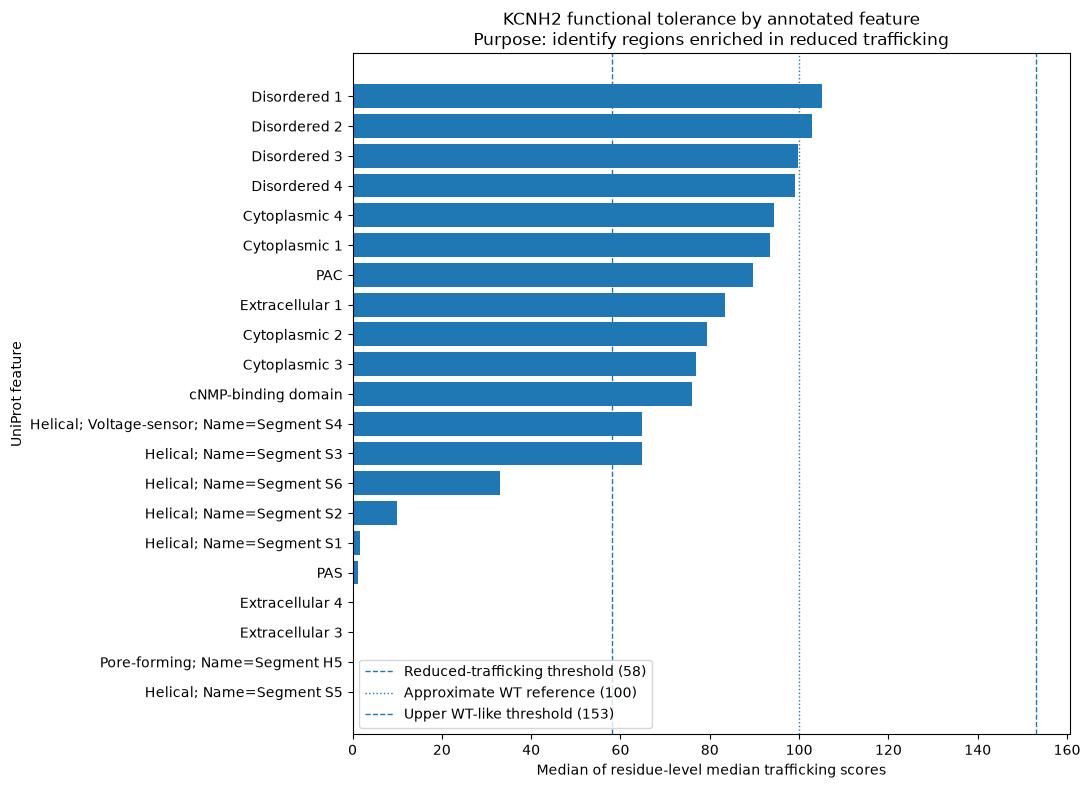

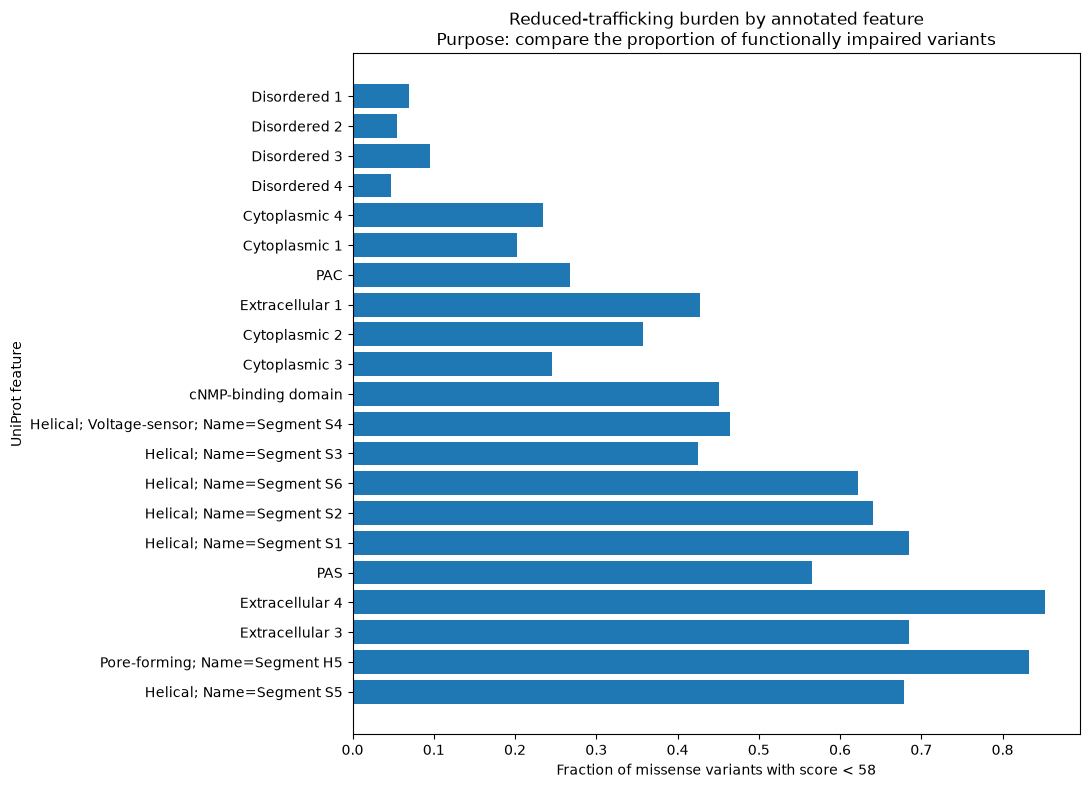

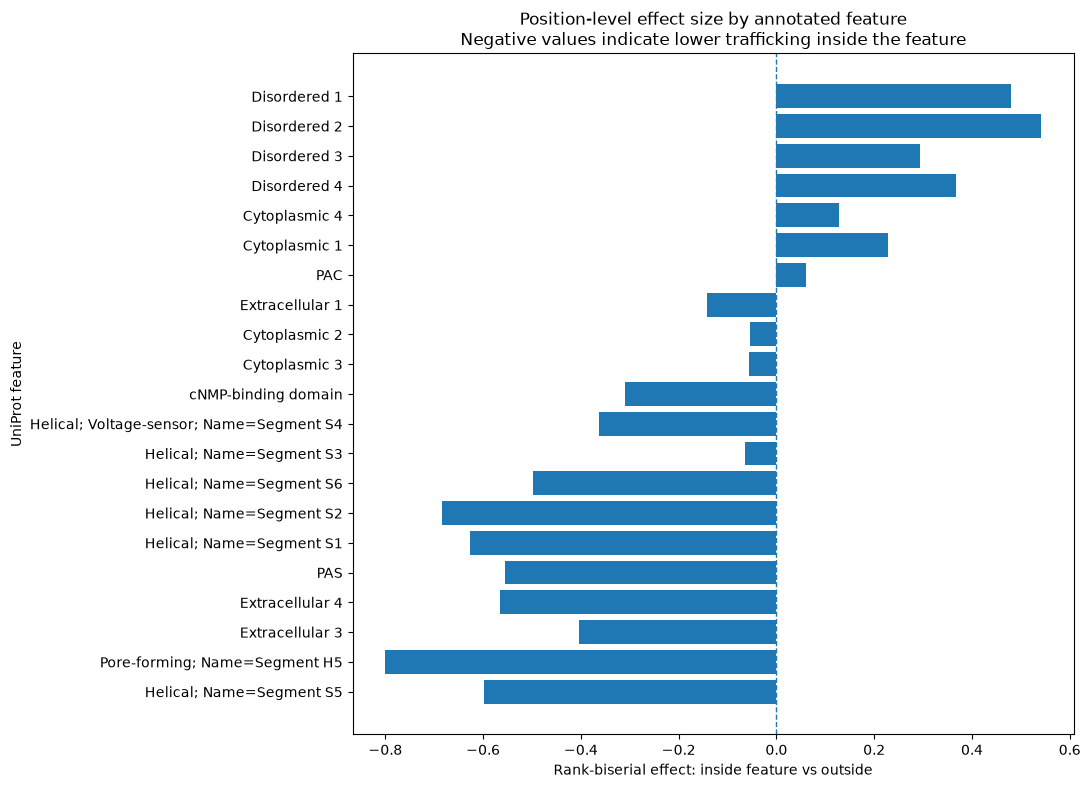

In [35]:
plot_summary = (
    domain_summary_df.loc[
        domain_summary_df[
            "n_observed_positions"
        ].ge(5)
    ]
    .sort_values(
        "position_median_score"
    )
)

plt.figure(
    figsize=(
        11,
        max(
            6,
            0.38 * len(plot_summary),
        ),
    )
)

plt.barh(
    plot_summary["feature_label"],
    plot_summary[
        "position_median_score"
    ],
)

plt.axvline(
    LOW_TRAFFICKING_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label="Reduced-trafficking threshold (58)",
)
plt.axvline(
    100,
    linestyle=":",
    linewidth=1,
    label="Approximate WT reference (100)",
)
plt.axvline(
    WT_LIKE_UPPER_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label="Upper WT-like threshold (153)",
)

plt.xlabel(
    "Median of residue-level median trafficking scores"
)
plt.ylabel("UniProt feature")
plt.title(
    "KCNH2 functional tolerance by annotated feature\n"
    "Purpose: identify regions enriched in reduced trafficking"
)
plt.legend()
plt.tight_layout()
plt.show()

# %%
plt.figure(
    figsize=(
        11,
        max(
            6,
            0.38 * len(plot_summary),
        ),
    )
)

plt.barh(
    plot_summary["feature_label"],
    plot_summary[
        "reduced_fraction_lt_58"
    ],
)

plt.xlabel(
    "Fraction of missense variants with score < 58"
)
plt.ylabel("UniProt feature")
plt.title(
    "Reduced-trafficking burden by annotated feature\n"
    "Purpose: compare the proportion of functionally impaired variants"
)
plt.tight_layout()
plt.show()

# %%
plt.figure(
    figsize=(
        11,
        max(
            6,
            0.38 * len(plot_summary),
        ),
    )
)

plt.barh(
    plot_summary["feature_label"],
    plot_summary[
        "rank_biserial_effect"
    ],
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1,
)

plt.xlabel(
    "Rank-biserial effect: inside feature vs outside"
)
plt.ylabel("UniProt feature")
plt.title(
    "Position-level effect size by annotated feature\n"
    "Negative values indicate lower trafficking inside the feature"
)
plt.tight_layout()
plt.show()

### 14.5 Sequence-level view — purpose: connect domain boundaries with residue-specific sensitivity

This plot shows residue-level median scores across the 1,159-amino-acid sequence. It should be interpreted together with the feature table because UniProt annotations can overlap.


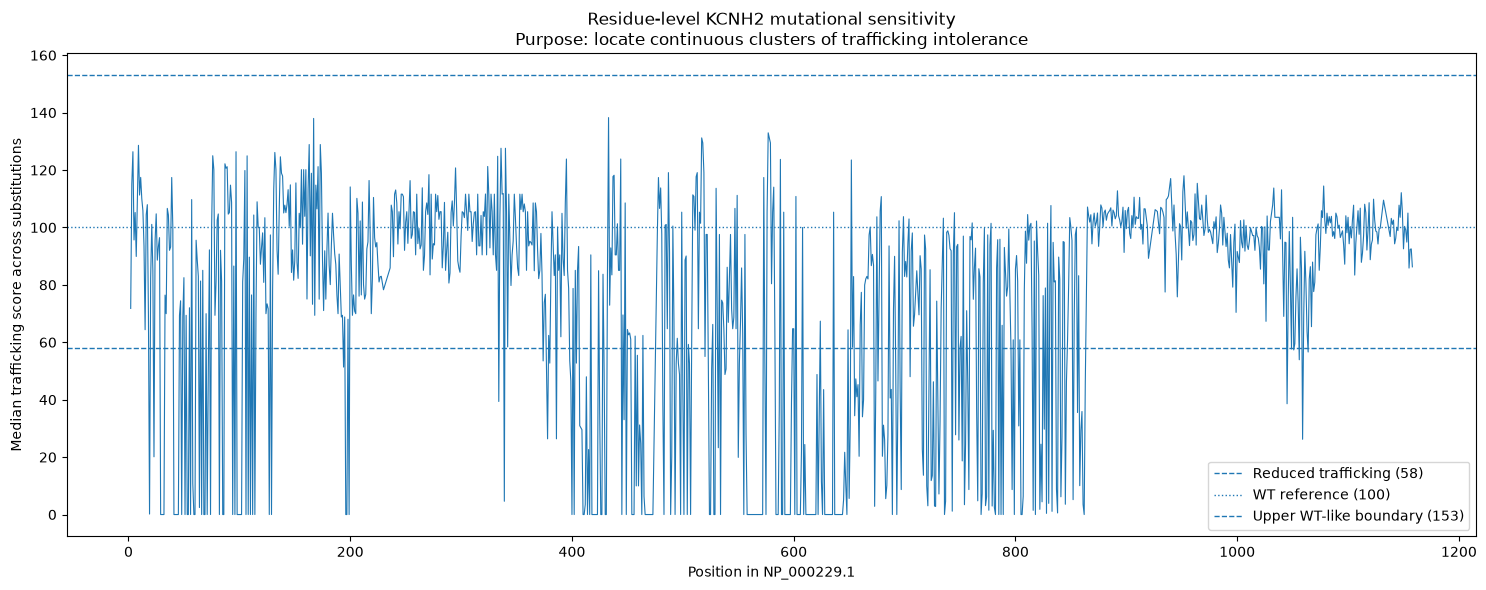

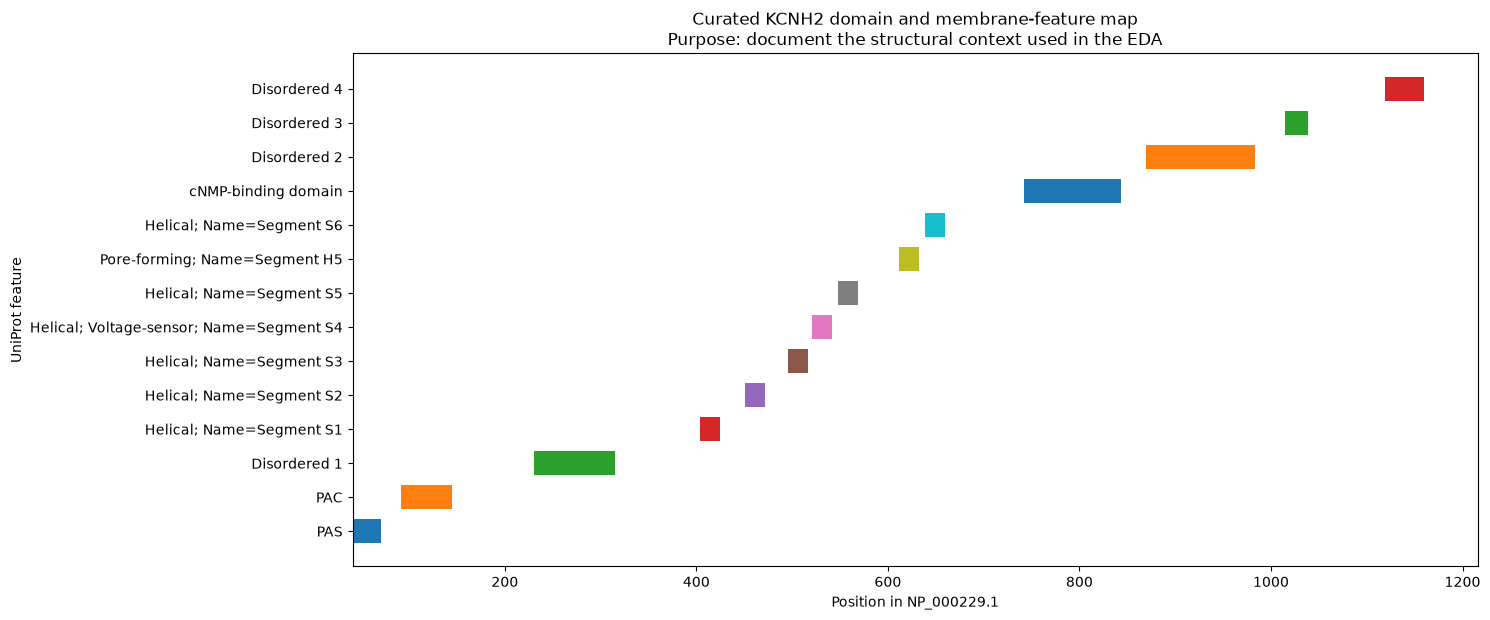

In [36]:
plt.figure(figsize=(15, 6))

plt.plot(
    position_score_summary["position"],
    position_score_summary[
        "median_score"
    ],
    linewidth=0.8,
)

plt.axhline(
    LOW_TRAFFICKING_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label="Reduced trafficking (58)",
)
plt.axhline(
    100,
    linestyle=":",
    linewidth=1,
    label="WT reference (100)",
)
plt.axhline(
    WT_LIKE_UPPER_THRESHOLD,
    linestyle="--",
    linewidth=1,
    label="Upper WT-like boundary (153)",
)

plt.xlabel("Position in NP_000229.1")
plt.ylabel(
    "Median trafficking score across substitutions"
)
plt.title(
    "Residue-level KCNH2 mutational sensitivity\n"
    "Purpose: locate continuous clusters of trafficking intolerance"
)
plt.legend()
plt.tight_layout()
plt.show()

# %%
track_features = analysis_features.loc[
    analysis_features[
        "feature_group"
    ].isin(
        {
            "domain",
            "region",
            "membrane",
        }
    )
].sort_values(
    ["start", "end"]
).reset_index(drop=True)

plt.figure(
    figsize=(
        15,
        max(
            5,
            0.45 * len(track_features),
        ),
    )
)

for row_index, feature in (
    track_features.iterrows()
):
    plt.barh(
        y=row_index,
        width=(
            int(feature["end"])
            - int(feature["start"])
            + 1
        ),
        left=int(feature["start"]),
        height=0.7,
    )

plt.yticks(
    ticks=np.arange(
        len(track_features)
    ),
    labels=track_features[
        "feature_label"
    ],
)

plt.xlabel("Position in NP_000229.1")
plt.ylabel("UniProt feature")
plt.title(
    "Curated KCNH2 domain and membrane-feature map\n"
    "Purpose: document the structural context used in the EDA"
)
plt.tight_layout()
plt.show()

### 14.6 Most intolerant residues within each feature — purpose: identify local hotspots that drive domain-level effects

A domain may have a low overall score because many residues are moderately sensitive or because a small cluster is extremely intolerant. Listing the lowest-scoring residues helps distinguish these patterns.


In [37]:
intolerant_position_rows = []

for feature in analysis_features.itertuples(
    index=False
):
    feature_positions = (
        position_score_summary.loc[
            position_score_summary[
                "position"
            ].between(
                int(feature.start),
                int(feature.end),
            )
        ]
        .sort_values(
            "median_score"
        )
        .head(10)
        .copy()
    )

    if feature_positions.empty:
        continue

    feature_positions.insert(
        0,
        "feature_label",
        feature.feature_label,
    )
    feature_positions.insert(
        1,
        "feature_group",
        feature.feature_group,
    )

    intolerant_position_rows.append(
        feature_positions
    )

if intolerant_position_rows:
    intolerant_positions_df = pd.concat(
        intolerant_position_rows,
        ignore_index=True,
    )
else:
    intolerant_positions_df = pd.DataFrame()

display(
    intolerant_positions_df.head(50)
)

intolerant_positions_df.to_csv(
    EDA_REPORTS_DIR
    / "kcnh2_intolerant_positions_by_feature.csv",
    index=False,
)


,feature_label,feature_group,position,wt_residue,n_variants,median_score,mean_score,q1_score,q3_score,iqr_score
0,PAS,domain,41,V,19,0.0000,18.9252,0.0000,9.9441,9.9441
1,PAS,domain,42,I,19,0.0000,14.7344,0.0000,0.0000,0.0000
2,PAS,domain,43,Y,19,0.0000,9.9104,0.0000,0.0000,0.0000
3,PAS,domain,44,C,19,0.0000,20.8849,0.0000,0.0000,0.0000
4,PAS,domain,45,N,19,0.0000,18.7579,0.0000,20.0212,20.0212
5,PAS,domain,48,F,19,0.0000,6.5138,0.0000,0.0000,0.0000
6,PAS,domain,56,R,19,0.0000,22.8507,0.0000,36.1203,36.1203
7,PAS,domain,51,L,19,0.0000,27.4867,0.0000,61.0803,61.0803
8,PAS,domain,54,Y,19,0.0000,10.8681,0.0000,0.0000,0.0000
9,PAS,domain,53,G,19,0.0000,14.7767,0.0000,0.0000,0.0000


### 14.7 Modeling dataset — purpose: convert biological annotations into reproducible machine-learning features

Each variant receives one binary column per UniProt feature. Overlapping annotations are preserved. These columns can be used by the biochemical baseline and the combined ESM-2 model.


In [38]:
position_feature_matrix = (
    position_feature_membership.assign(
        present=1
    )
    .pivot_table(
        index="position",
        columns="feature_label",
        values="present",
        aggfunc="max",
        fill_value=0,
    )
    .reset_index()
)

position_feature_matrix.columns = [
    (
        "domain__"
        + str(column)
        .strip()
        .lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
        .replace("(", "")
        .replace(")", "")
    )
    if column != "position"
    else "position"
    for column in position_feature_matrix.columns
]

missense_with_domains = (
    domain_variant_base.merge(
        position_feature_matrix,
        on="position",
        how="left",
        validate="many_to_one",
    )
)

domain_feature_columns = [
    column
    for column in missense_with_domains.columns
    if column.startswith("domain__")
]

missense_with_domains[
    domain_feature_columns
] = missense_with_domains[
    domain_feature_columns
].fillna(0).astype("int8")

DOMAIN_DATASET_PATH = (
    INTERIM_DIR
    / "kcnh2_variants_with_domains.parquet"
)

missense_with_domains.to_parquet(
    DOMAIN_DATASET_PATH,
    index=False,
)

print(
    f"Domain feature columns: "
    f"{len(domain_feature_columns)}"
)
print(
    f"Output: {DOMAIN_DATASET_PATH}"
)

assert len(
    missense_with_domains
) == len(domain_variant_base)

Domain feature columns: 22
Output: /home/diego/Desktop/Github Repos/byte2beat-cardiovus/data/interim/kcnh2_variants_with_domains.parquet


### 14.8 Domain-analysis conclusions — purpose: document biological interpretation before model training

After running the cells, summarize:

1. Which domains or membrane regions have the lowest residue-level median scores?
2. Which features have the highest fraction of variants below 58?
3. Which differences remain significant after Holm correction?
4. Are negative effects broad across the feature or driven by a small hotspot?
5. Do transmembrane or pore-associated regions show greater intolerance than long terminal regions?
6. Which domain annotations should be included as model features?
7. Which findings concern trafficking only and should not be generalized to complete channel function?

Add the answers to Sections 17.3, 17.7, and 17.8 of the EDA conclusions.

## 15. Decisiones de modelamiento — propósito: convertir el EDA en una metodología justificable

El EDA debe justificar target, filtros, features y validación. La validación principal será `GroupKFold(group=position)` para evaluar generalización hacia residuos no observados.

In [31]:
modeling_decisions = pd.DataFrame(
    {
        "decision": [
            "Target",
            "Unidad de observación",
            "Validación",
            "Baseline",
            "Representación avanzada",
            "Columnas excluidas",
            "Incertidumbre",
            "Interpretación clínica",
        ],
        "choice": [
            "score_numeric",
            "Una sustitución missense",
            "GroupKFold por position",
            (
                "Propiedades fisicoquímicas "
                "+ BLOSUM62"
            ),
            (
                "Diferencia de embeddings "
                "ESM-2 WT vs mutante"
            ),
            (
                "score, se, LLR y "
                "columnas derivadas"
            ),
            (
                "No filtrar todavía; "
                "hacer análisis de sensibilidad"
            ),
            (
                "Priorización funcional, "
                "no clasificación ACMG"
            ),
        ],
        "biological_reason": [
            (
                "Medición experimental "
                "continua"
            ),
            (
                "Atribución a un cambio "
                "único"
            ),
            (
                "Generalización a residuos "
                "no vistos"
            ),
            (
                "Cambios químicos "
                "interpretables"
            ),
            (
                "Contexto de secuencia"
            ),
            (
                "Target leakage"
            ),
            (
                "Evitar eliminar datos "
                "prematuramente"
            ),
            (
                "El tráfico no captura "
                "toda la evidencia clínica"
            ),
        ],
    }
)

display(modeling_decisions)

modeling_decisions.to_csv(
    EDA_REPORTS_DIR
    / "modeling_decisions.csv",
    index=False,
)

,decision,choice,biological_reason
0,Target,score_numeric,Medición experimental continua
1,Unidad de observación,Una sustitución missense,Atribución a un cambio único
2,Validación,GroupKFold por position,Generalización a residuos no vistos
3,Baseline,Propiedades fisicoquímicas + BLOSUM62,Cambios químicos interpretables
4,Representación avanzada,Diferencia de embeddings ESM-2 WT vs mutante,Contexto de secuencia
5,Columnas excluidas,"score, se, LLR y columnas derivadas",Target leakage
6,Incertidumbre,No filtrar todavía; hacer análisis de sensibilidad,Evitar eliminar datos prematuramente
7,Interpretación clínica,"Priorización funcional, no clasificación ACMG",El tráfico no captura toda la evidencia clínica


## 16. Exportación — propósito: guardar resultados pequeños y auditables para GitHub

Se guardan tablas resumidas y un JSON central. Los datos crudos y Parquet pesados permanecen fuera del repositorio.

In [32]:
core_summary = {
    "reference": {
        "id": reference_record.id,
        "length": len(
            reference_sequence
        ),
    },
    "datasets": {
        "raw_rows": int(
            len(raw_scores)
        ),
        "qc_rows": int(
            len(qc_df)
        ),
        "normalized_missense_rows": int(
            len(missense_df)
        ),
    },
    "variant_classes": {
        str(row["variant_class"]): int(
            row["count"]
        )
        for _, row
        in variant_class_summary.iterrows()
    },
    "quality": {
        "numeric_scores": int(
            qc_df[
                "score_numeric"
            ].notna().sum()
        ),
        "reference_matches": int(
            qc_df[
                "ref_match"
            ].eq(True).sum()
        ),
        "reference_mismatches": int(
            qc_df[
                "ref_match"
            ].eq(False).sum()
        ),
        "protein_duplicate_rows": int(
            qc_df[
                "protein_variant_duplicate"
            ].sum()
        ),
    },
    "coverage": {
        key: (
            float(value)
            if isinstance(
                value,
                (float, np.floating),
            )
            else int(value)
        )
        for key, value
        in coverage_summary.items()
    },
    "score_medians": {
        label: float(
            class_score_summary.loc[
                label,
                "median",
            ]
        )
        for label
        in class_score_summary.index
    },
    "score_llr_spearman": float(
        spearman_llr.statistic
    ),
    "score_se_spearman": float(
        se_score_corr.statistic
    ),
}

summary_path = (
    EDA_REPORTS_DIR
    / "eda_core_summary.json"
)

with summary_path.open(
    "w",
    encoding="utf-8",
) as file:
    json.dump(
        core_summary,
        file,
        indent=2,
        ensure_ascii=False,
    )

print(
    f"Resumen: {summary_path}"
)
print(
    f"Tablas: {EDA_REPORTS_DIR}"
)

Resumen: /home/diego/Desktop/Github Repos/byte2beat-cardiovus/reports/eda/eda_core_summary.json
Tablas: /home/diego/Desktop/Github Repos/byte2beat-cardiovus/reports/eda


## 17. Conclusiones — propósito: documentar hallazgos biológicos, experimentales y metodológicos

Completa esta sección después de ejecutar el notebook y revisar sus resultados.

### Hallazgos experimentales
- ¿Qué representa el score?
- ¿Qué dirección y normalización fueron confirmadas?
- ¿Qué tan bien separa controles synonymous y stop-gained?
- ¿Qué limitaciones tiene el ensayo?

### Hallazgos bioinformáticos
- ¿Qué porcentaje del espacio missense está cubierto?
- ¿Hay posiciones sin datos?
- ¿Qué aporta `mapped_variants.json`?
- ¿Existe coherencia total con `NP_000229.1`?

### Hallazgos biológicos
- ¿Qué posiciones presentan scores bajos de forma consistente?
- ¿Qué posiciones dependen del aminoácido mutante?
- ¿Qué cambios fisicoquímicos se asocian con el score?

### Decisiones para el modelo
- Target y filtros.
- GroupKFold por posición.
- Features bioquímicas.
- Embeddings ESM-2.
- Análisis de sensibilidad por incertidumbre.

### Limitaciones
- Tráfico superficial no equivale a función electrofisiológica completa.
- Score funcional no equivale a clasificación clínica.
- HEK293 no reproduce completamente un cardiomiocito.
- La integración con ClinVar requiere armonización independiente.

## 17. Conclusiones — propósito: integrar los hallazgos biológicos, experimentales y metodológicos del EDA

### 17.1 Hallazgos experimentales

El score analizado representa una medición continua de tráfico o expresión superficial de variantes de KCNH2, normalizada aproximadamente respecto al canal wild-type. Las variantes synonymous presentaron una media de 99,3 y una mediana de 102,9, lo que establece un comportamiento WT-like alrededor de 100. En contraste, las variantes stop-gained presentaron una mediana de cero, consistente con una pérdida marcada de expresión superficial.

Las variantes missense mostraron un comportamiento intermedio y altamente heterogéneo, con una mediana de 85,4. Esto indica que una proporción importante de las sustituciones conserva total o parcialmente el tráfico, mientras que otro subconjunto produce pérdidas funcionales severas.

La comparación entre synonymous, missense y stop-gained mostró diferencias estadísticamente claras y tamaños de efecto relevantes. Por tanto, el ensayo posee suficiente rango dinámico para distinguir variantes con comportamientos biológicos diferentes y constituye un target apropiado para modelamiento predictivo.

El score no debe interpretarse como probabilidad de patogenicidad ni como medición completa de la función del canal. Evalúa principalmente la capacidad de KCNH2 para alcanzar la superficie celular. Una variante con tráfico normal todavía puede presentar alteraciones de gating, conductancia, selectividad iónica o regulación.

La distribución presentó un límite inferior aparente en cero y valores superiores a 100. Los valores cercanos a cero representan pérdida marcada de tráfico, mientras que los valores alrededor de 100 representan comportamiento WT-like. Los valores superiores a 100 indican mayor expresión superficial relativa, pero no implican automáticamente benignidad ni ganancia de función electrofisiológica.

### 17.2 Hallazgos bioinformáticos

El dataset contiene 22.824 variantes proteicas:

* 20.683 variantes missense simples;
* 1.084 variantes stop-gained;
* 1.057 variantes synonymous.

No se encontraron variantes múltiples, scores faltantes, variantes missense duplicadas ni inconsistencias entre el aminoácido de referencia declarado por MaveDB y la secuencia `NP_000229.1`.

Las 20.683 variantes missense mostraron correspondencia completa con la secuencia de referencia. Aunque el accession `NP_000229.1` no aparece explícitamente en los metadatos inspeccionados, la numeración y los aminoácidos experimentales son totalmente compatibles con esta referencia.

El experimento cubre aproximadamente el 93,92 % del espacio missense teórico de KCNH2. Se observaron variantes en 1.100 de las 1.159 posiciones de la proteína y 967 posiciones contienen las 19 sustituciones aminoacídicas posibles. Las 59 posiciones sin variantes deben considerarse vacíos de cobertura experimental y no evidencia de tolerancia o restricción biológica.

La cobertura casi saturada permite formular una tarea de machine learning especialmente rigurosa: predecir el efecto de sustituciones localizadas en residuos completamente ausentes del entrenamiento.

El archivo `mapped_variants.json` contiene representaciones estandarizadas que podrán utilizarse posteriormente para armonizar los resultados con ClinVar y otras fuentes. Su integración detallada no es necesaria para el modelamiento funcional inicial, pero será importante durante la validación clínica externa.

### 17.3 Hallazgos biológicos

La sensibilidad mutacional no está distribuida uniformemente a lo largo de KCNH2.

Se identificaron posiciones donde prácticamente todas las sustituciones producen scores muy bajos. Algunas presentan una mediana y un rango intercuartílico iguales a cero, lo que indica una intolerancia amplia a la variación. Estos residuos probablemente son esenciales para el plegamiento, estabilidad, ensamblaje o arquitectura molecular del canal.

También se observaron posiciones con mediana baja pero alta variabilidad entre sustituciones. En estos residuos, el efecto no depende únicamente de la posición, sino de las propiedades del aminoácido introducido. Algunas sustituciones pueden conservar el tráfico mientras otras lo eliminan.

Las posiciones con scores medianos superiores al WT representan regiones tolerantes o sustituciones que aumentan la señal superficial. Estos valores no deben interpretarse automáticamente como clínicamente benignos, ya que una alta presencia del canal en la membrana no garantiza una función electrofisiológica normal.

El análisis de dominios proteicos será necesario para establecer si los clústeres de posiciones intolerantes se concentran en regiones como dominios globulares, segmentos transmembrana, poro o interfaces estructurales.

### 17.4 Propiedades fisicoquímicas

Las características fisicoquímicas simples presentaron asociaciones significativas pero débiles con el score funcional.

BLOSUM62 mostró la asociación monotónica más fuerte, con una correlación de Spearman de aproximadamente 0,20. Esto indica que sustituciones evolutivamente más conservadoras tienden a preservar mejor el tráfico, pero el efecto es insuficiente para explicar por sí solo la variación experimental.

El cambio absoluto de hidrofobicidad mostró una correlación negativa débil. Los cambios químicos más grandes tienden a asociarse con menor tráfico, aunque existen numerosas excepciones.

Las sustituciones que introducen carga en residuos originalmente neutrales mostraron un primer cuartil notablemente menor. Esto sugiere que introducir una carga puede ser especialmente perjudicial en determinados entornos estructurales, pero las medianas similares entre categorías demuestran que el efecto depende fuertemente de la posición y del contexto local.

En conjunto, estos resultados muestran que las propiedades bioquímicas serán útiles como baseline interpretable, pero no capturan toda la complejidad de la relación secuencia-función. Esto justifica incorporar embeddings de ESM-2, capaces de representar el contexto aminoacídico alrededor de cada variante.

### 17.5 Incertidumbre experimental

Las medidas de incertidumbre están disponibles para la gran mayoría de las variantes. Solo aproximadamente el 0,86 % carece de error estándar o intervalos de confianza del LLR.

No se encontró evidencia suficiente para excluir inicialmente variantes con base en su error estándar. Los scores extremos no parecen ser sistemáticamente menos precisos, y la concentración de errores altos alrededor de valores WT-like puede estar influenciada por la mayor densidad de observaciones en esa región.

El modelo principal se entrenará inicialmente con todas las variantes missense elegibles. Posteriormente se realizará un análisis de sensibilidad utilizando variantes con menor incertidumbre o mayor fuerza de evidencia.

Las medidas `se`, `LLR`, `LLR_ci_lower`, `LLR_ci_upper` y `LLR_evidence_strength` no se utilizarán como features predictivas, ya que se derivan del mismo experimento utilizado para construir el target y producirían target leakage.

### 17.6 Interpretación del LLR

El LLR no constituye una segunda medición funcional independiente. Representa una calibración de la fuerza de evidencia generada por el assay, basada en la distribución de variantes clínicas conocidas.

Valores positivos favorecen evidencia funcional hacia patogenicidad; valores negativos favorecen evidencia hacia benignidad; y valores cercanos a cero indican evidencia insuficiente, indeterminada o fuera del rango calibrado.

La relación entre score y LLR es no lineal. Los scores muy bajos reciben evidencia patogénica fuerte porque representan pérdida severa de tráfico. El rango WT-like recibe evidencia benigna. Los scores extremadamente elevados pueden retornar hacia un LLR cercano a cero debido a que el ensayo no cuenta necesariamente con suficientes controles clínicos para interpretar el hipertráfico como evidencia benigna o patogénica.

Las categorías de `LLR_evidence_strength` representan niveles de evidencia funcional y no una clasificación clínica final. Una variante requiere integrar información poblacional, segregación, fenotipo, mecanismo molecular y otras evidencias para realizar una clasificación ACMG/AMP.

### 17.7 Decisiones para el modelamiento

El target principal será `score_numeric`, tratado como una variable continua de tráfico superficial.

La unidad de análisis será una sustitución missense individual.

La validación principal utilizará `GroupKFold` agrupado por posición. Todas las sustituciones de un mismo residuo permanecerán dentro del mismo fold. Esta estrategia evaluará si el modelo puede generalizar hacia posiciones que nunca observó durante el entrenamiento y evitará que memorice la sensibilidad particular de cada residuo.

El baseline utilizará:

* propiedades fisicoquímicas;
* identidad de los aminoácidos WT y mutante;
* BLOSUM62;
* cambios de carga, polaridad e hidrofobicidad;
* posición y, posteriormente, dominio proteico.

El modelo avanzado incorporará embeddings de ESM-2 derivados de secuencias WT y mutantes. La representación principal será la diferencia entre ambos embeddings, con el objetivo de capturar el cambio contextual producido por la sustitución.

La métrica principal será Spearman, debido a que interesa evaluar la capacidad del modelo para ordenar variantes según su impacto funcional sin asumir una relación lineal. También se reportarán MAE, RMSE y Pearson.

Debido al límite inferior aparente en cero y a la distribución no normal del score, se realizará un análisis de errores específico para variantes con pérdida completa de tráfico y valores extremos. Si resulta necesario, se comparará la regresión continua con una formulación complementaria basada en categorías funcionales.

### 17.8 Limitaciones

El ensayo fue realizado en un sistema celular experimental y no reproduce completamente la fisiología de un cardiomiocito humano.

La expresión superficial representa solo una dimensión de la función de KCNH2. Variantes con tráfico normal pueden presentar defectos de gating, conducción, permeabilidad o regulación.

Los scores funcionales no equivalen directamente a clasificación clínica, riesgo de arritmia ni gravedad del síndrome de QT largo.

La interpretación estructural definitiva permanece pendiente del análisis de dominios proteicos.

Existe una diferencia entre las 22.824 filas presentes en el score set descargado y las 18.796 variantes descritas en el análisis principal de la publicación. Esta discrepancia puede reflejar filtros de calidad, criterios de inclusión o diferencias entre la biblioteca completa y el subconjunto utilizado en los análisis publicados. Debe conservarse como una limitación de trazabilidad hasta identificar la explicación exacta en los métodos o archivos suplementarios.

### 17.9 Conclusión general

El EDA demuestra que el score set de MaveDB constituye un mapa funcional de alta calidad y cobertura casi saturada para KCNH2.

El dataset permite estudiar de forma sistemática cómo la posición, la identidad aminoacídica y el contexto molecular determinan el tráfico superficial del canal. Los efectos muestran una fuerte dependencia posicional que no puede explicarse únicamente mediante propiedades fisicoquímicas simples.

Estos hallazgos justifican desarrollar un modelo que combine features bioquímicas interpretables con representaciones contextuales de ESM-2. La validación agrupada por residuo permitirá evaluar una tarea relevante para medicina de precisión: priorizar el efecto funcional de variantes localizadas en posiciones no caracterizadas experimentalmente.

El producto resultante deberá interpretarse como una herramienta de priorización e integración de evidencia funcional, no como un sistema autónomo de diagnóstico o clasificación clínica.


## 17. Conclusions — Purpose: Integrate the Biological, Experimental, and Methodological Findings of the EDA

### 17.1 Experimental findings

The analyzed score represents a continuous measurement of KCNH2 surface trafficking or surface expression, approximately normalized relative to the wild-type channel. Synonymous variants had a mean score of 99.3 and a median of 102.9, establishing a wild-type-like behavior around 100. In contrast, stop-gained variants had a median score of zero, consistent with a marked loss of surface expression.

Missense variants displayed an intermediate and highly heterogeneous behavior, with a median score of 85.4. This indicates that a substantial proportion of amino acid substitutions retain full or partial surface trafficking, whereas another subset causes severe functional loss.

The comparison among synonymous, missense, and stop-gained variants revealed clear statistical differences and biologically meaningful effect sizes. Therefore, the assay provides sufficient dynamic range to distinguish variants with different molecular behaviors and constitutes an appropriate prediction target.

The score should not be interpreted as a probability of pathogenicity or as a complete measurement of channel function. It primarily evaluates the ability of KCNH2/Kv11.1 to reach the cell surface. A variant with normal trafficking may still exhibit abnormal gating, conductance, ion selectivity, or regulation.

The score distribution showed an apparent lower boundary at zero and included values above 100. Values close to zero represent markedly reduced or absent trafficking, whereas values around 100 represent wild-type-like behavior. Values above 100 indicate increased relative surface expression but do not automatically imply clinical benignity or electrophysiological gain of function.

### 17.2 Bioinformatic findings

The dataset contains 22,824 protein variants:

* 20,683 simple missense variants;
* 1,084 stop-gained variants;
* 1,057 synonymous variants.

No multi-variant records, missing experimental scores, duplicated missense protein variants, or inconsistencies between the MaveDB reference amino acid and the `NP_000229.1` sequence were identified.

All 20,683 missense variants were fully consistent with the selected reference sequence. Although the accession `NP_000229.1` was not explicitly identified in the inspected metadata, the experimental residue numbering and wild-type amino acids were completely compatible with this reference.

The experiment covers approximately 93.92% of the theoretical KCNH2 missense-variant space. Missense variants were observed at 1,100 of the 1,159 protein positions, and 967 positions contained all 19 possible amino acid substitutions. The 59 positions without missense variants should be interpreted as experimental coverage gaps rather than evidence of biological tolerance or constraint.

This nearly saturated coverage enables a particularly rigorous machine-learning task: predicting the functional effects of substitutions located at residues that were completely absent from the training data.

The `mapped_variants.json` file contains standardized variant representations that may later support harmonization with ClinVar and other external resources. Its detailed integration is not required for the initial functional model but will be important during external clinical validation.

### 17.3 Biological findings

Mutational sensitivity is not uniformly distributed throughout KCNH2.

Several positions were identified where nearly all amino acid substitutions produced very low scores. Some residues had both a median and an interquartile range equal to zero, indicating broad intolerance to variation. These positions are likely important for protein folding, structural stability, subunit assembly, or overall channel architecture.

Other positions showed a low median score but high variability among substitutions. At these residues, the outcome depends not only on the position itself but also on the physicochemical properties of the introduced amino acid. Some substitutions may preserve trafficking, whereas others nearly eliminate it.

Positions with median scores above the wild-type reference represent tolerant regions or substitutions that increase surface signal. However, these values should not automatically be interpreted as clinically benign because increased membrane localization does not guarantee normal electrophysiological function.

Protein-domain analysis will be required to determine whether clusters of intolerant residues are concentrated within globular domains, transmembrane segments, the channel pore, or other structurally important regions.

### 17.4 Physicochemical properties

Simple physicochemical features showed statistically significant but weak associations with the functional score.

BLOSUM62 produced the strongest monotonic association, with a Spearman correlation of approximately 0.20. This indicates that evolutionarily conservative substitutions tend to preserve trafficking more effectively, but evolutionary similarity alone explains only a limited proportion of the observed functional variability.

The absolute change in hydrophobicity showed a weak negative correlation with the score. Larger chemical changes therefore tend to be associated with reduced trafficking, although many exceptions were observed.

Substitutions that introduced a positive or negative charge into an originally neutral residue showed a notably lower first quartile. This suggests that introducing charge can be highly disruptive in specific structural environments. However, the similar median scores across charge-change categories demonstrate that the effect depends strongly on residue position and local molecular context.

Overall, these findings indicate that physicochemical properties provide a useful and interpretable baseline but cannot capture the full complexity of the sequence–function relationship. This supports the inclusion of ESM-2 embeddings, which can represent the broader amino acid context surrounding each variant.

### 17.5 Experimental uncertainty

Uncertainty measurements were available for the vast majority of variants. Only approximately 0.86% of records lacked a standard error or LLR confidence interval.

There was insufficient evidence to exclude variants based solely on their standard error during the initial analysis. Extreme scores were not systematically associated with lower precision, and the apparent concentration of larger standard errors around wild-type-like scores may partly reflect the greater density of observations within that region.

The primary model will therefore be trained using all eligible missense variants. A subsequent sensitivity analysis will evaluate whether performance and conclusions remain stable when restricting the data to variants with lower uncertainty or stronger experimental evidence.

The variables `se`, `LLR`, `LLR_ci_lower`, `LLR_ci_upper`, and `LLR_evidence_strength` will not be used as predictive features. They are derived from the same experimental evidence used to define or calibrate the target and would therefore introduce target leakage.

### 17.6 Interpretation of the LLR

The LLR is not an independent measurement of KCNH2 trafficking. It represents a calibration of the strength of functional evidence based on the distributions of clinically characterized benign and pathogenic variants.

Positive LLR values favor functional evidence toward pathogenicity, negative values favor evidence toward benignity, and values near zero indicate insufficient, indeterminate, or poorly calibrated evidence.

The relationship between the trafficking score and the LLR is nonlinear. Very low trafficking scores receive strong pathogenic evidence because they resemble variants with severe loss of surface expression. Scores within the wild-type-like range receive benign evidence. Extremely high scores may return toward an LLR near zero because the assay may not contain enough clinically characterized controls to interpret excessive surface expression as either benign or pathogenic evidence.

The `LLR_evidence_strength` categories represent levels of functional evidence rather than final clinical classifications. Formal ACMG/AMP classification would also require population frequency, segregation, phenotype, molecular mechanism, computational evidence, and other independent sources of information.

### 17.7 Modeling decisions

The primary prediction target will be `score_numeric`, treated as a continuous measurement of surface trafficking.

The unit of analysis will be one individual missense substitution.

The primary validation strategy will use `GroupKFold`, grouped by protein position. All substitutions affecting the same residue will remain within the same fold. This approach will evaluate whether the model can generalize to positions that were never observed during training and will prevent the model from simply memorizing position-specific sensitivity.

The baseline model will use:

* physicochemical properties;
* wild-type and mutant amino acid identity;
* BLOSUM62;
* changes in charge, polarity, and hydrophobicity;
* residue position;
* protein-domain annotations when available.

The advanced model will incorporate ESM-2 embeddings derived from wild-type and mutant sequences. The primary representation will be the difference between mutant and wild-type embeddings, with the goal of capturing the contextual effect introduced by each substitution.

Spearman correlation will be the primary evaluation metric because the model should correctly rank variants according to functional impact without assuming a strictly linear relationship. MAE, RMSE, and Pearson correlation will also be reported.

Because the score has an apparent lower boundary at zero and a non-normal distribution, error analysis will specifically examine variants with complete trafficking loss and variants with extreme values. If necessary, continuous regression will be complemented by a functional-category classification analysis.

### 17.8 Limitations

The assay was performed in an experimental cellular system and does not fully reproduce the physiology of a human cardiomyocyte.

Surface expression captures only one dimension of KCNH2 function. Variants with normal trafficking may still have defects in gating, conductance, permeability, or channel regulation.

Functional scores do not directly represent clinical classification, arrhythmia risk, QT-interval duration, or disease severity.

The definitive structural interpretation remains pending until protein-domain annotations are integrated.

A discrepancy remains between the 22,824 records contained in the downloaded score set and the 18,796 variants described in the primary analysis of the associated publication. This difference may reflect quality filters, inclusion criteria, control variants, or differences between the complete experimental library and the subset used in the published analyses. It should remain documented as a provenance limitation until the exact explanation is identified in the methods or supplementary materials.

### 17.9 Overall conclusion

The EDA demonstrates that the selected MaveDB score set constitutes a high-quality, nearly saturated functional map of KCNH2 variation.

The dataset enables a systematic evaluation of how residue position, amino acid identity, and local molecular context determine Kv11.1 surface trafficking. The observed effects show a strong position-dependent component that cannot be explained solely by simple physicochemical properties.

These findings support the development of a model combining interpretable biochemical features with contextual ESM-2 representations. Residue-grouped validation will evaluate a task directly relevant to precision medicine: prioritizing the functional effects of variants located at positions that have not been experimentally characterized.

The resulting system should be interpreted as a research tool for functional variant prioritization and evidence integration, not as an autonomous diagnostic or clinical-classification system.
